In [14]:
import numpy as np
import os

gt = np.load("model_comparison/ground_truth.npy")
mask = np.load("./data/oisst_spatial_mask_ecs.npy") 

gt shape: (1792, 7, 1, 32, 32)
mask shape: (32, 32)
Start date: 2021-01-15
End date  : 2025-12-11

Season counts:
Winter: 417
Spring: 460
Summer: 460
Autumn: 455


/home/perseverance/lim/openstl-env/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


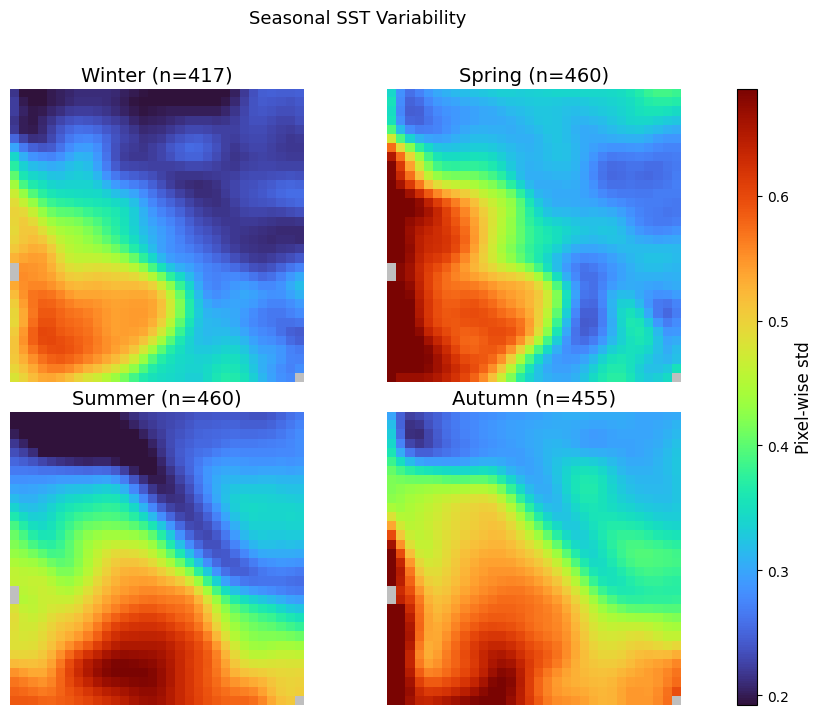

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

# =========================================================
# 1. 설정
# =========================================================
gt_path = "model_comparison/ground_truth.npy"
mask_path = "./data/oisst_spatial_mask_ecs.npy"

start_date = "2021-01-15"
date_freq = "D"

save_fig = False
save_path = "seasonal_variability_maps_clean.png"

# 네가 준 color 느낌 중 하나 선택
# variability map은 양수값만 있으니까 sequential colormap이 맞음
cmap_name = "turbo"     # 추천
# cmap_name = "jet"     # 더 강한 느낌 원하면 이걸로 바꿔도 됨

mask_color = "#BFBFBF"  # mask 바깥 회색
interp_mode = "nearest" # "nearest" or "bilinear"


# =========================================================
# 2. 유틸 함수
# =========================================================
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


def prepare_gt_for_variability(gt):
    """
    지원 shape:
      - (N, T, C, H, W)
      - (N, T, H, W)
      - (N, H, W)

    return:
      obs: (num_observations, H, W)
    """
    gt = np.asarray(gt)

    if gt.ndim == 5:
        # (N, T, C, H, W)
        gt = gt[:, :, 0, :, :]   # 첫 채널만 사용
        N, T, H, W = gt.shape
        obs = gt.reshape(N * T, H, W)

    elif gt.ndim == 4:
        # (N, T, H, W)
        N, T, H, W = gt.shape
        obs = gt.reshape(N * T, H, W)

    elif gt.ndim == 3:
        # (N, H, W)
        obs = gt

    else:
        raise ValueError(f"Unsupported gt shape: {gt.shape}")

    return obs


def compute_seasonal_variability_maps(gt, mask, date_indices, metric="std"):
    """
    metric:
      - "std"  : 픽셀별 표준편차
      - "diff" : 시간 차분 절대값 평균
    """
    gt = np.asarray(gt)
    mask = np.squeeze(mask).astype(np.float32)

    if len(date_indices) != gt.shape[0]:
        raise ValueError(
            f"len(date_indices)={len(date_indices)} but gt.shape[0]={gt.shape[0]}"
        )

    season_labels = np.array([month_to_season(d.month) for d in date_indices])

    seasonal_maps = {}
    season_counts = {}

    for season in ["Winter", "Spring", "Summer", "Autumn"]:
        idx = np.where(season_labels == season)[0]
        season_counts[season] = len(idx)

        if len(idx) == 0:
            seasonal_maps[season] = None
            continue

        gt_s = gt[idx]
        obs = prepare_gt_for_variability(gt_s)  # (M, H, W)

        # mask 바깥은 NaN
        obs = np.where(mask[None, :, :] > 0, obs, np.nan)

        if metric == "std":
            var_map = np.nanstd(obs, axis=0)
        elif metric == "diff":
            if obs.shape[0] < 2:
                var_map = np.full(obs.shape[1:], np.nan, dtype=np.float32)
            else:
                diff_obs = np.abs(np.diff(obs, axis=0))
                var_map = np.nanmean(diff_obs, axis=0)
        else:
            raise ValueError("metric must be 'std' or 'diff'")

        seasonal_maps[season] = np.where(mask > 0, var_map, np.nan)

    return seasonal_maps, season_counts


def plot_seasonal_maps_clean(
    seasonal_maps,
    season_counts,
    cmap_name="turbo",
    mask_color="#BFBFBF",
    title="Seasonal SST Variability",
    cbar_label="Pixel-wise std",
    figsize=(10, 8),
    interpolation="nearest",
    save_path=None
):
    seasons = ["Winter", "Spring", "Summer", "Autumn"]

    # -----------------------------
    # 공통 color range
    # -----------------------------
    valid_vals = []
    for s in seasons:
        m = seasonal_maps.get(s, None)
        if m is not None:
            vals = m[~np.isnan(m)]
            if vals.size > 0:
                valid_vals.append(vals)

    if len(valid_vals) == 0:
        raise ValueError("No valid seasonal maps found.")

    valid_vals = np.concatenate(valid_vals)
    vmin = np.nanpercentile(valid_vals, 2)
    vmax = np.nanpercentile(valid_vals, 98)

    # -----------------------------
    # colormap
    # -----------------------------
    cmap = mpl.colormaps[cmap_name].copy()
    cmap.set_bad(mask_color)

    # -----------------------------
    # figure / layout
    # colorbar 축을 따로 빼서 안 겹치게
    # -----------------------------
    fig = plt.figure(figsize=figsize, facecolor="white")
    gs = GridSpec(
        2, 3,
        figure=fig,
        width_ratios=[1, 1, 0.06],
        wspace=0.12,
        hspace=0.10
    )

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
    ]
    cax = fig.add_subplot(gs[:, 2])

    im = None
    for ax, season in zip(axes, seasons):
        m = seasonal_maps[season]

        im = ax.imshow(
            m,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation=interpolation
        )

        ax.set_title(f"{season} (n={season_counts[season]})", fontsize=14, pad=6)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor(mask_color)

        for spine in ax.spines.values():
            spine.set_visible(False)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(cbar_label, fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    fig.suptitle(title, fontsize=13, y=0.98)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# =========================================================
# 3. 데이터 로드
# =========================================================
gt = np.load(gt_path)
mask = np.load(mask_path).astype(np.float32)
mask = np.squeeze(mask)

print("gt shape:", gt.shape)
print("mask shape:", mask.shape)

date_indices = pd.date_range(
    start=start_date,
    periods=gt.shape[0],
    freq=date_freq
)

print("Start date:", date_indices[0].date())
print("End date  :", date_indices[-1].date())


# =========================================================
# 4. 계절별 변동성 계산
# =========================================================
seasonal_maps, season_counts = compute_seasonal_variability_maps(
    gt=gt,
    mask=mask,
    date_indices=date_indices,
    metric="std"   # 또는 "diff"
)

print("\nSeason counts:")
for k, v in season_counts.items():
    print(f"{k}: {v}")


# =========================================================
# 5. 시각화
# =========================================================
plot_seasonal_maps_clean(
    seasonal_maps=seasonal_maps,
    season_counts=season_counts,
    cmap_name=cmap_name,
    mask_color=mask_color,
    title="Seasonal SST Variability",
    cbar_label="Pixel-wise std",
    figsize=(10, 8),
    interpolation=interp_mode,
    save_path=save_path if save_fig else None
)

if save_fig:
    print(f"Saved to: {save_path}")

GT shape: (1792, 7, 1, 32, 32)
ConvLSTM: (1792, 7, 1, 32, 32)
msfv3_gdl03: (1792, 7, 1, 32, 32)
predrnn: (1792, 7, 1, 32, 32)
ViT_GRU: (1792, 7, 1, 32, 32)

=== Selected new P1/P2/P3 ===
P1: (y=14, x=23) ~ approx lat/lon=(29.39N, 127.94E)
P2: (y=16, x=16) ~ approx lat/lon=(28.87N, 126.13E)
P3: (y=25, x=9) ~ approx lat/lon=(26.55N, 124.32E)


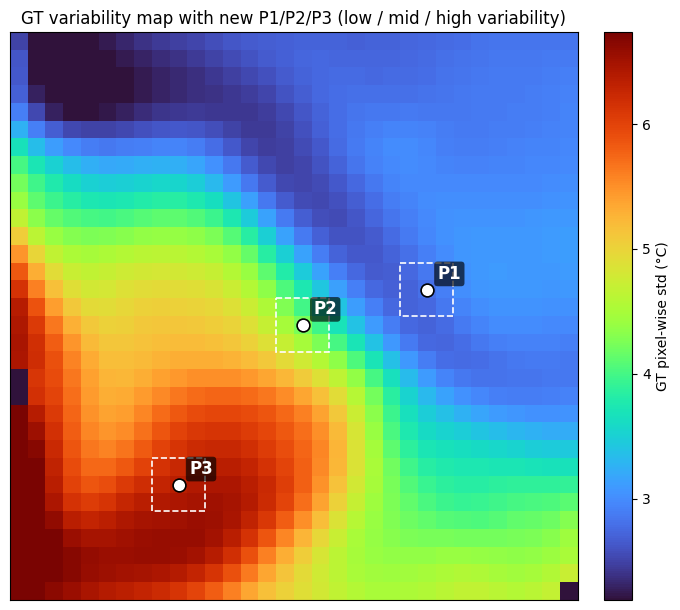


=== Selected samples ===
[Representative] sample_idx=271, forecast_start=2021-10-27, score_mean=0.3807
[Challenging]    sample_idx=141, forecast_start=2021-06-19, score_mean=0.7014


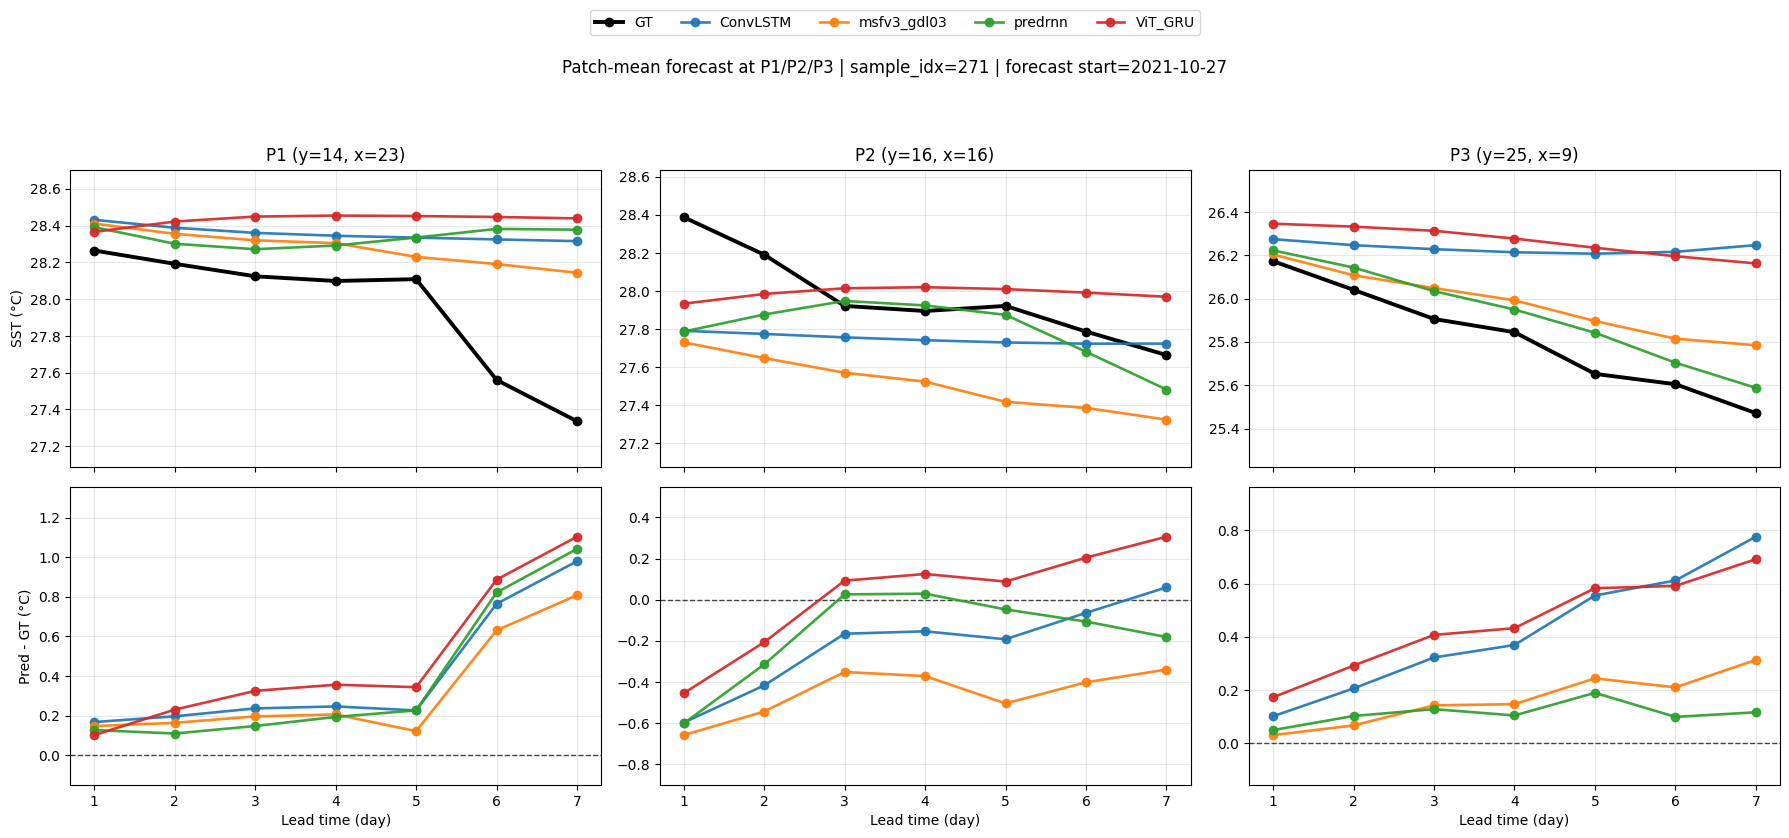

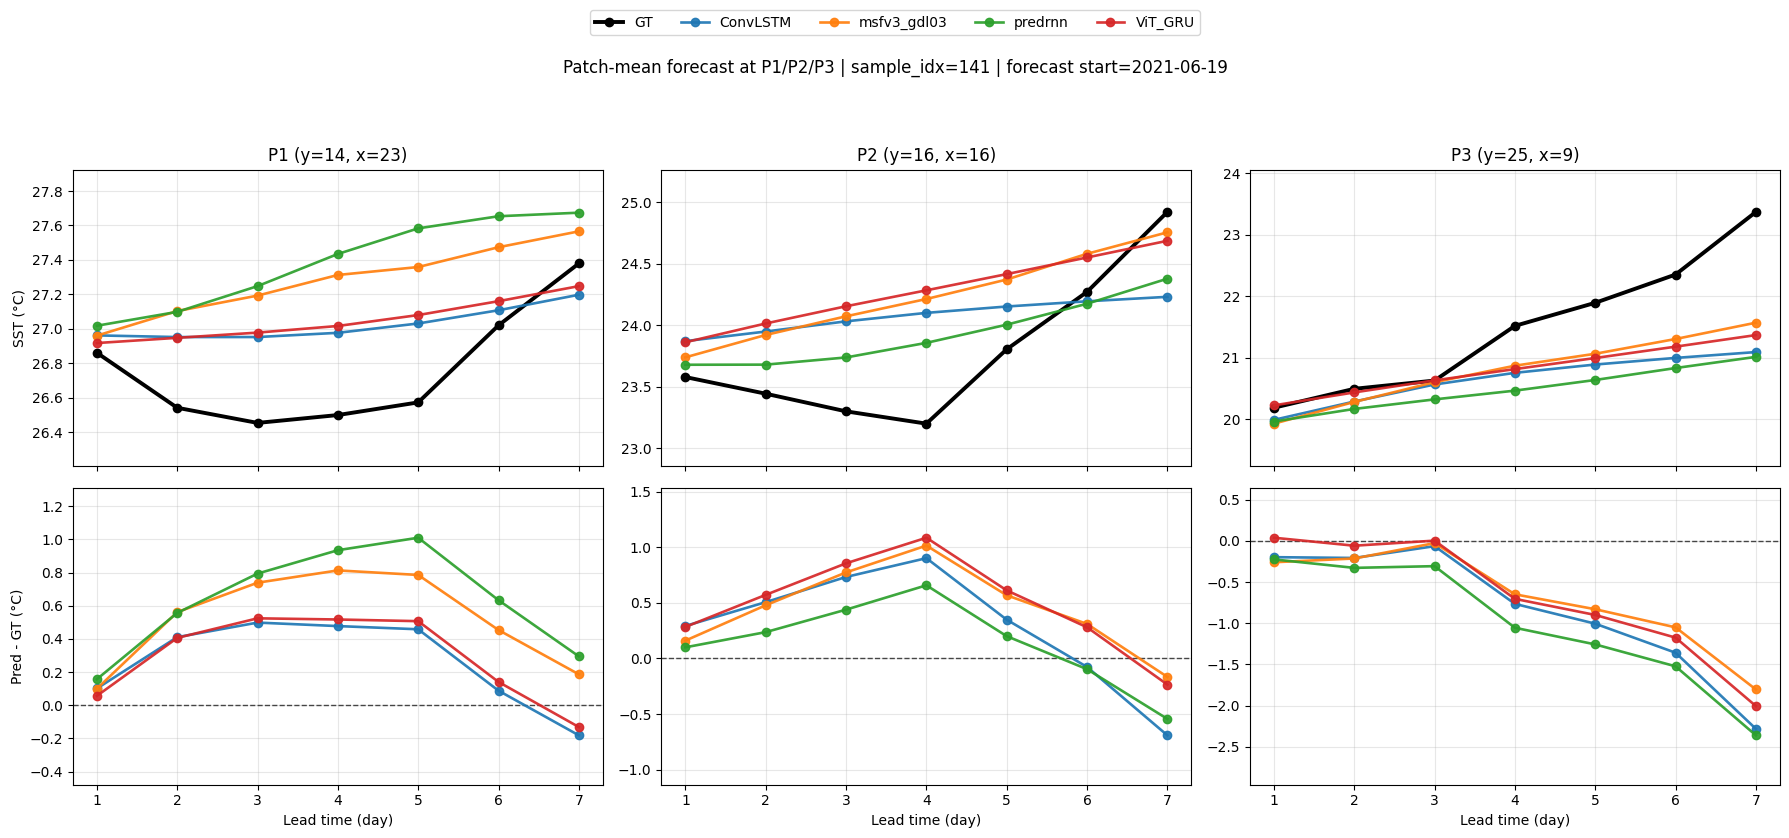

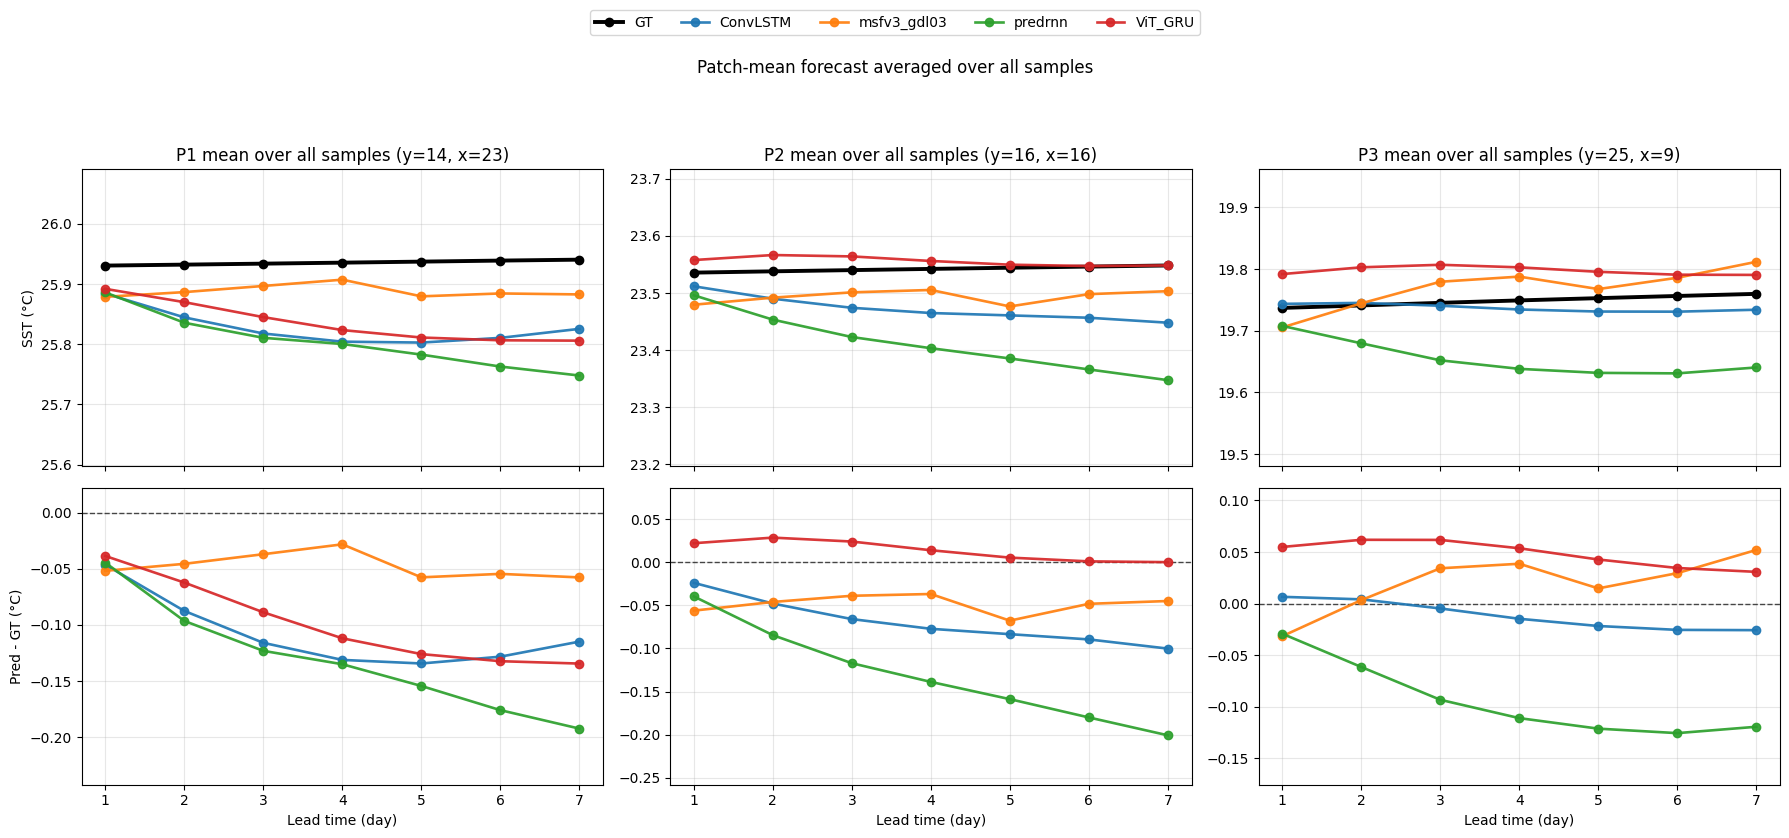

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

GT_PATH = "model_comparison/ground_truth.npy"
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"
PRED_DIR = "model_comparison"

MODEL_NAMES = [
    "ConvLSTM",
    "msfv3_gdl03",
    "predrnn",
    "ViT_GRU",
]

DATA_START_DATE = "2021-01-15"
TIN = 14
PATCH_SIZE = 3
HIGH_QUANTILE = 0.90


def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def load_saved_predictions(model_names, pred_dir=PRED_DIR):
    preds_dict = {}
    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if os.path.exists(path):
            preds_dict[name] = np.load(path)
        else:
            print(f"[WARN] Missing file: {path}")
    return preds_dict


def sample_idx_to_date(sample_idx, start_date=DATA_START_DATE, tin=TIN):
    return pd.to_datetime(start_date) + pd.Timedelta(days=int(sample_idx + tin))


def index_to_latlon(y, x, H, W,
                    lat_min=25.0, lat_max=33.0,
                    lon_min=122.0, lon_max=130.0):
    lat_vals = np.linspace(lat_max, lat_min, H)
    lon_vals = np.linspace(lon_min, lon_max, W)
    return float(lat_vals[y]), float(lon_vals[x])


def build_valid_patch_mask(mask, patch_size=3):
    mask = np.asarray(mask)
    H, W = mask.shape
    r = patch_size // 2
    valid = np.zeros((H, W), dtype=bool)

    for y in range(r, H - r):
        for x in range(r, W - r):
            local = mask[y-r:y+r+1, x-r:x+r+1]
            if np.all(local > 0):
                valid[y, x] = True
    return valid


def compute_gt_variability_map(gt, denorm=True, mean=MEAN_SST, std=STD_SST):
    arr = np.asarray(gt)
    if arr.ndim != 5:
        raise ValueError(f"gt must be (N,T,C,H,W), got {arr.shape}")

    x = arr[:, :, 0, :, :]

    if denorm:
        x = denorm_sst(x, mean=mean, std=std)

    N, T, H, W = x.shape
    x2 = x.reshape(N * T, H, W)
    var_map = np.nanstd(x2, axis=0)
    return var_map


def make_variability_roi_masks(H, W):
    yy, xx = np.mgrid[0:H, 0:W]
    roi_masks = {}

    roi_masks["P1"] = (
        (xx >= int(W * 0.58)) & (xx <= int(W * 0.90)) &
        (yy >= int(H * 0.15)) & (yy <= int(H * 0.70))
    )

    roi_masks["P2"] = (
        (xx >= int(W * 0.30)) & (xx <= int(W * 0.72)) &
        (yy >= int(H * 0.28)) & (yy <= int(H * 0.78))
    )

    roi_masks["P3"] = (
        (xx >= int(W * 0.05)) & (xx <= int(W * 0.42)) &
        (yy >= int(H * 0.35)) & (yy <= int(H * 0.88))
    )

    return roi_masks


def choose_point_from_quantile(field, roi_mask, valid_patch_mask,
                               q_low, q_high, prefer_center=True):
    H, W = field.shape
    yy, xx = np.mgrid[0:H, 0:W]

    candidate_mask = roi_mask & valid_patch_mask & np.isfinite(field)
    if np.sum(candidate_mask) == 0:
        raise ValueError("No valid candidates in ROI.")

    vals = field[candidate_mask]
    lo = np.nanpercentile(vals, q_low)
    hi = np.nanpercentile(vals, q_high)

    target_mask = candidate_mask & (field >= lo) & (field <= hi)

    if np.sum(target_mask) < 3:
        mid = np.nanpercentile(vals, (q_low + q_high) / 2.0)
        tol = max(1e-6, 0.15 * np.nanstd(vals))
        target_mask = candidate_mask & (np.abs(field - mid) <= tol)

    if np.sum(target_mask) == 0:
        target_mask = candidate_mask

    ys = yy[target_mask]
    xs = xx[target_mask]
    vs = field[target_mask]

    roi_ys = yy[roi_mask]
    roi_xs = xx[roi_mask]
    cy = np.mean(roi_ys)
    cx = np.mean(roi_xs)

    target_v = np.nanpercentile(vals, (q_low + q_high) / 2.0)

    dist = np.sqrt((ys - cy) ** 2 + (xs - cx) ** 2)
    dist = dist / (dist.max() + 1e-8)

    vscore = np.abs(vs - target_v)
    vscore = vscore / (vscore.max() + 1e-8)

    if prefer_center:
        score = 0.65 * dist + 0.35 * vscore
    else:
        score = vscore

    idx = np.argmin(score)
    return int(ys[idx]), int(xs[idx])


def choose_points_low_mid_high(gt, mask, patch_size=3,
                               denorm=True, mean=MEAN_SST, std=STD_SST):
    H, W = mask.shape
    valid_patch_mask = build_valid_patch_mask(mask, patch_size=patch_size)
    var_map = compute_gt_variability_map(gt, denorm=denorm, mean=mean, std=std)
    roi_masks = make_variability_roi_masks(H, W)

    points = {}
    points["P1"] = choose_point_from_quantile(
        var_map, roi_masks["P1"], valid_patch_mask,
        q_low=10, q_high=30, prefer_center=True
    )
    points["P2"] = choose_point_from_quantile(
        var_map, roi_masks["P2"], valid_patch_mask,
        q_low=45, q_high=60, prefer_center=True
    )
    points["P3"] = choose_point_from_quantile(
        var_map, roi_masks["P3"], valid_patch_mask,
        q_low=75, q_high=92, prefer_center=True
    )

    return points, var_map, roi_masks, valid_patch_mask


def plot_selected_points_on_variability_map(var_map, points, title=None):
    cmap = mpl.colormaps["turbo"].copy()
    cmap.set_bad("#BFBFBF")

    vals = var_map[np.isfinite(var_map)]
    vmin = np.nanpercentile(vals, 2)
    vmax = np.nanpercentile(vals, 98)

    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    im = ax.imshow(var_map, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title if title is not None else "GT variability map with P1/P2/P3")

    for name, (y, x) in points.items():
        ax.scatter(x, y, s=85, c="white", edgecolors="black", linewidths=1.2, zorder=5)
        ax.text(
            x + 0.6, y - 0.6, name,
            color="white", fontsize=12, weight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.65),
            zorder=6
        )
        rect = plt.Rectangle(
            (x - 1.5, y - 1.5), 3, 3,
            fill=False, edgecolor="white", linewidth=1.2, linestyle="--", zorder=4
        )
        ax.add_patch(rect)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("GT pixel-wise std (°C)")
    plt.tight_layout()
    plt.show()


def extract_patch_mean_series(arr, center, patch_size=3, channel=0,
                              denorm=False, mean=MEAN_SST, std=STD_SST):
    arr = np.asarray(arr)
    y, x = center
    r = patch_size // 2

    if arr.ndim == 5:
        patch = arr[:, :, channel, y-r:y+r+1, x-r:x+r+1]
        out = np.nanmean(patch, axis=(-2, -1))
    elif arr.ndim == 4:
        patch = arr[:, :, y-r:y+r+1, x-r:x+r+1]
        out = np.nanmean(patch, axis=(-2, -1))
    else:
        raise ValueError(f"Unsupported shape: {arr.shape}")

    if denorm:
        out = denorm_sst(out, mean=mean, std=std)

    return out


def compute_samplewise_point_rmse(gt, pred, points, patch_size=3,
                                  denorm=True, mean=MEAN_SST, std=STD_SST):
    if gt.shape != pred.shape:
        raise ValueError(f"Shape mismatch: gt={gt.shape}, pred={pred.shape}")

    point_rmses = []

    for _, center in points.items():
        gt_series = extract_patch_mean_series(
            gt, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
        )
        pred_series = extract_patch_mean_series(
            pred, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
        )
        rmse = np.sqrt(np.nanmean((pred_series - gt_series) ** 2, axis=1))
        point_rmses.append(rmse)

    point_rmses = np.stack(point_rmses, axis=1)
    rmse_per_sample = np.nanmean(point_rmses, axis=1)
    return rmse_per_sample


def build_sample_score_table(gt, preds_dict, points, patch_size=3,
                             denorm=True, mean=MEAN_SST, std=STD_SST):
    model_scores = {}
    for model_name, pred in preds_dict.items():
        rmse_per_sample = compute_samplewise_point_rmse(
            gt, pred, points,
            patch_size=patch_size,
            denorm=denorm,
            mean=mean,
            std=std
        )
        model_scores[model_name] = rmse_per_sample

    df = pd.DataFrame(model_scores)
    df["sample_idx"] = np.arange(len(df))

    score_cols = list(preds_dict.keys())
    df["score_mean"] = df[score_cols].mean(axis=1)
    df["score_std"] = df[score_cols].std(axis=1)
    df["forecast_start"] = df["sample_idx"].apply(sample_idx_to_date)

    return df


def select_representative_and_challenging_samples(score_df, q_high=0.90):
    score = score_df["score_mean"].values

    median_val = np.nanmedian(score)
    rep_idx = int(score_df.iloc[np.argmin(np.abs(score - median_val))]["sample_idx"])

    q_val = np.nanquantile(score, q_high)
    chal_idx = int(score_df.iloc[np.argmin(np.abs(score - q_val))]["sample_idx"])

    return rep_idx, chal_idx


def print_selected_sample_summary(score_df, rep_idx, chal_idx):
    rep_row = score_df[score_df["sample_idx"] == rep_idx].iloc[0]
    chal_row = score_df[score_df["sample_idx"] == chal_idx].iloc[0]

    print("\n=== Selected samples ===")
    print(f"[Representative] sample_idx={rep_idx}, "
          f"forecast_start={rep_row['forecast_start'].date()}, "
          f"score_mean={rep_row['score_mean']:.4f}")
    print(f"[Challenging]    sample_idx={chal_idx}, "
          f"forecast_start={chal_row['forecast_start'].date()}, "
          f"score_mean={chal_row['score_mean']:.4f}")


def _panel_ylim(series_list, min_pad_deg=0.25, frac_pad=0.20):
    vals = np.concatenate([np.ravel(s) for s in series_list if s is not None])
    ymin = np.nanmin(vals)
    ymax = np.nanmax(vals)
    yr = ymax - ymin
    pad = max(min_pad_deg, frac_pad * yr)
    return ymin - pad, ymax + pad


def plot_patch_forecast_for_sample_readable(
    gt,
    preds_dict,
    points,
    sample_idx=0,
    patch_size=3,
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    figsize=(18, 8),
    min_pad_deg=0.25,
    frac_pad=0.20,
):
    if gt.ndim != 5:
        raise ValueError(f"gt must be (N,T,C,H,W), got {gt.shape}")

    N, T, C, H, W = gt.shape
    if not (0 <= sample_idx < N):
        raise ValueError(f"sample_idx {sample_idx} out of range 0~{N-1}")

    lead = np.arange(1, T + 1)
    point_names = list(points.keys())

    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True)
    top_axes = axes[0]
    bot_axes = axes[1]

    for col, pname in enumerate(point_names):
        center = points[pname]

        gt_series_all = extract_patch_mean_series(
            gt, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
        )
        gt_series = gt_series_all[sample_idx]

        pred_series_dict = {}
        err_series_dict = {}
        for model_name, pred in preds_dict.items():
            pred_series_all = extract_patch_mean_series(
                pred, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
            )
            pred_series = pred_series_all[sample_idx]
            pred_series_dict[model_name] = pred_series
            err_series_dict[model_name] = pred_series - gt_series

        ax = top_axes[col]
        ax.plot(lead, gt_series, marker="o", linewidth=2.8, label="GT")

        for model_name, pred_series in pred_series_dict.items():
            ax.plot(lead, pred_series, marker="o", linewidth=1.9, alpha=0.92, label=model_name)

        y, x = center
        ax.set_title(f"{pname} (y={y}, x={x})")
        ax.grid(True, alpha=0.3)

        y1, y2 = _panel_ylim(
            [gt_series] + list(pred_series_dict.values()),
            min_pad_deg=min_pad_deg,
            frac_pad=frac_pad
        )
        ax.set_ylim(y1, y2)

        ax2 = bot_axes[col]
        ax2.axhline(0.0, linestyle="--", linewidth=1.0, color="black", alpha=0.7)

        for model_name, err_series in err_series_dict.items():
            ax2.plot(lead, err_series, marker="o", linewidth=1.9, alpha=0.92, label=model_name)

        ax2.grid(True, alpha=0.3)
        ey1, ey2 = _panel_ylim(
            list(err_series_dict.values()),
            min_pad_deg=0.10,
            frac_pad=0.25
        )
        ax2.set_ylim(ey1, ey2)
        ax2.set_xlabel("Lead time (day)")

    top_axes[0].set_ylabel("SST (°C)")
    bot_axes[0].set_ylabel("Pred - GT (°C)")

    forecast_date = sample_idx_to_date(sample_idx)
    fig.suptitle(
        f"Patch-mean forecast at P1/P2/P3 | sample_idx={sample_idx} | forecast start={forecast_date.date()}",
        y=0.98
    )

    handles, labels = top_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.05))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def plot_patch_forecast_for_sample_readable(
    gt,
    preds_dict,
    points,
    sample_idx=0,
    patch_size=3,
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    figsize=(18, 8),
    min_pad_deg=0.25,
    frac_pad=0.20,
):
    if gt.ndim != 5:
        raise ValueError(f"gt must be (N,T,C,H,W), got {gt.shape}")

    N, T, C, H, W = gt.shape
    if not (0 <= sample_idx < N):
        raise ValueError(f"sample_idx {sample_idx} out of range 0~{N-1}")

    lead = np.arange(1, T + 1)
    point_names = list(points.keys())
    model_names = list(preds_dict.keys())

    # 핵심: 모델별 색상을 고정
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    model_colors = {
        model_name: cycle_colors[i % len(cycle_colors)]
        for i, model_name in enumerate(model_names)
    }
    gt_color = "black"

    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True)
    top_axes = axes[0]
    bot_axes = axes[1]

    for col, pname in enumerate(point_names):
        center = points[pname]

        gt_series_all = extract_patch_mean_series(
            gt, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
        )
        gt_series = gt_series_all[sample_idx]

        pred_series_dict = {}
        err_series_dict = {}
        for model_name, pred in preds_dict.items():
            pred_series_all = extract_patch_mean_series(
                pred, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
            )
            pred_series = pred_series_all[sample_idx]
            pred_series_dict[model_name] = pred_series
            err_series_dict[model_name] = pred_series - gt_series

        ax = top_axes[col]
        ax.plot(
            lead, gt_series,
            marker="o", linewidth=2.8, label="GT",
            color=gt_color
        )

        for model_name, pred_series in pred_series_dict.items():
            ax.plot(
                lead, pred_series,
                marker="o", linewidth=1.9, alpha=0.92, label=model_name,
                color=model_colors[model_name]
            )

        y, x = center
        ax.set_title(f"{pname} (y={y}, x={x})")
        ax.grid(True, alpha=0.3)

        y1, y2 = _panel_ylim(
            [gt_series] + list(pred_series_dict.values()),
            min_pad_deg=min_pad_deg,
            frac_pad=frac_pad
        )
        ax.set_ylim(y1, y2)

        ax2 = bot_axes[col]
        ax2.axhline(0.0, linestyle="--", linewidth=1.0, color="black", alpha=0.7)

        for model_name, err_series in err_series_dict.items():
            ax2.plot(
                lead, err_series,
                marker="o", linewidth=1.9, alpha=0.92, label=model_name,
                color=model_colors[model_name]
            )

        ax2.grid(True, alpha=0.3)
        ey1, ey2 = _panel_ylim(
            list(err_series_dict.values()),
            min_pad_deg=0.10,
            frac_pad=0.25
        )
        ax2.set_ylim(ey1, ey2)
        ax2.set_xlabel("Lead time (day)")

    top_axes[0].set_ylabel("SST (°C)")
    bot_axes[0].set_ylabel("Pred - GT (°C)")

    forecast_date = sample_idx_to_date(sample_idx)
    fig.suptitle(
        f"Patch-mean forecast at P1/P2/P3 | sample_idx={sample_idx} | forecast start={forecast_date.date()}",
        y=0.98
    )

    handles, labels = top_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.05))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def plot_patch_forecast_mean_over_samples_readable(
    gt,
    preds_dict,
    points,
    patch_size=3,
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    figsize=(18, 8),
    min_pad_deg=0.15,
    frac_pad=0.20,
):
    if gt.ndim != 5:
        raise ValueError(f"gt must be (N,T,C,H,W), got {gt.shape}")

    N, T, C, H, W = gt.shape
    lead = np.arange(1, T + 1)
    point_names = list(points.keys())
    model_names = list(preds_dict.keys())

    # 핵심: 모델별 색상을 고정
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    model_colors = {
        model_name: cycle_colors[i % len(cycle_colors)]
        for i, model_name in enumerate(model_names)
    }
    gt_color = "black"

    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True)
    top_axes = axes[0]
    bot_axes = axes[1]

    for col, pname in enumerate(point_names):
        center = points[pname]

        gt_series_all = extract_patch_mean_series(
            gt, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
        )
        gt_mean = np.nanmean(gt_series_all, axis=0)

        pred_mean_dict = {}
        err_mean_dict = {}
        for model_name, pred in preds_dict.items():
            pred_series_all = extract_patch_mean_series(
                pred, center, patch_size=patch_size, denorm=denorm, mean=mean, std=std
            )
            pred_mean = np.nanmean(pred_series_all, axis=0)
            pred_mean_dict[model_name] = pred_mean
            err_mean_dict[model_name] = pred_mean - gt_mean

        ax = top_axes[col]
        ax.plot(
            lead, gt_mean,
            marker="o", linewidth=2.8, label="GT",
            color=gt_color
        )

        for model_name, pred_mean in pred_mean_dict.items():
            ax.plot(
                lead, pred_mean,
                marker="o", linewidth=1.9, alpha=0.92, label=model_name,
                color=model_colors[model_name]
            )

        y, x = center
        ax.set_title(f"{pname} mean over all samples (y={y}, x={x})")
        ax.grid(True, alpha=0.3)

        y1, y2 = _panel_ylim(
            [gt_mean] + list(pred_mean_dict.values()),
            min_pad_deg=min_pad_deg,
            frac_pad=frac_pad
        )
        ax.set_ylim(y1, y2)

        ax2 = bot_axes[col]
        ax2.axhline(0.0, linestyle="--", linewidth=1.0, color="black", alpha=0.7)

        for model_name, err_mean in err_mean_dict.items():
            ax2.plot(
                lead, err_mean,
                marker="o", linewidth=1.9, alpha=0.92, label=model_name,
                color=model_colors[model_name]
            )

        ax2.grid(True, alpha=0.3)
        ey1, ey2 = _panel_ylim(
            list(err_mean_dict.values()),
            min_pad_deg=0.05,
            frac_pad=0.25
        )
        ax2.set_ylim(ey1, ey2)
        ax2.set_xlabel("Lead time (day)")

    top_axes[0].set_ylabel("SST (°C)")
    bot_axes[0].set_ylabel("Pred - GT (°C)")

    fig.suptitle("Patch-mean forecast averaged over all samples", y=0.98)

    handles, labels = top_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.05))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


gt = np.load(GT_PATH)
mask = np.load(MASK_PATH)
preds_dict = load_saved_predictions(MODEL_NAMES)

print("GT shape:", gt.shape)
for k, v in preds_dict.items():
    print(f"{k}: {v.shape}")

points, var_map, roi_masks, valid_patch_mask = choose_points_low_mid_high(
    gt=gt,
    mask=mask,
    patch_size=PATCH_SIZE,
    denorm=True
)

print("\n=== Selected new P1/P2/P3 ===")
for name, (y, x) in points.items():
    lat, lon = index_to_latlon(y, x, mask.shape[0], mask.shape[1])
    print(f"{name}: (y={y}, x={x}) ~ approx lat/lon=({lat:.2f}N, {lon:.2f}E)")

plot_selected_points_on_variability_map(
    var_map,
    points,
    title="GT variability map with new P1/P2/P3 (low / mid / high variability)"
)

score_df = build_sample_score_table(
    gt=gt,
    preds_dict=preds_dict,
    points=points,
    patch_size=PATCH_SIZE,
    denorm=True
)

rep_idx, chal_idx = select_representative_and_challenging_samples(
    score_df,
    q_high=HIGH_QUANTILE
)

print_selected_sample_summary(score_df, rep_idx, chal_idx)

plot_patch_forecast_for_sample_readable(
    gt=gt,
    preds_dict=preds_dict,
    points=points,
    sample_idx=rep_idx,
    patch_size=PATCH_SIZE,
    denorm=True,
)

plot_patch_forecast_for_sample_readable(
    gt=gt,
    preds_dict=preds_dict,
    points=points,
    sample_idx=chal_idx,
    patch_size=PATCH_SIZE,
    denorm=True,
)

plot_patch_forecast_mean_over_samples_readable(
    gt=gt,
    preds_dict=preds_dict,
    points=points,
    patch_size=PATCH_SIZE,
    denorm=True,
)

In [17]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# 설정
# =========================================================
MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

GT_PATH = "model_comparison/ground_truth.npy"
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"
PRED_DIR = "model_comparison"

MODEL_NAMES = [
    "ConvLSTM",
    "msfv3_base03",
    "predrnn",
    "ViT_GRU",
]

SAVE_FIG = True
OUT_FIG = "model_error_maps_rmse.png"


# =========================================================
# 유틸
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def load_saved_predictions(model_names, pred_dir=PRED_DIR):
    preds_dict = {}
    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if os.path.exists(path):
            preds_dict[name] = np.load(path)
        else:
            print(f"[WARN] Missing file: {path}")
    return preds_dict


def apply_mask_nan(field, mask):
    out = np.asarray(field).copy()
    out[np.asarray(mask) <= 0] = np.nan
    return out


def compute_pixel_error_map(pred, gt, metric="mae", denorm=True, mean=MEAN_SST, std=STD_SST):
    """
    pred, gt:
      - (N, T, C, H, W)
      - (N, T, H, W)
    return:
      - (H, W)
    """
    pred = np.asarray(pred)
    gt = np.asarray(gt)

    if pred.shape != gt.shape:
        raise ValueError(f"Shape mismatch: pred={pred.shape}, gt={gt.shape}")

    if pred.ndim == 5:
        pred2 = pred[:, :, 0, :, :]
        gt2 = gt[:, :, 0, :, :]
    elif pred.ndim == 4:
        pred2 = pred
        gt2 = gt
    else:
        raise ValueError(f"Unsupported shape: {pred.shape}")

    if denorm:
        pred2 = denorm_sst(pred2, mean=mean, std=std)
        gt2 = denorm_sst(gt2, mean=mean, std=std)

    err = pred2 - gt2  # (N, T, H, W)

    if metric == "mae":
        out = np.nanmean(np.abs(err), axis=(0, 1))
    elif metric == "rmse":
        out = np.sqrt(np.nanmean(err ** 2, axis=(0, 1)))
    elif metric == "bias":
        out = np.nanmean(err, axis=(0, 1))
    else:
        raise ValueError(f"Unsupported metric: {metric}")

    return out


def plot_error_maps(
    preds_dict, gt, mask, metric="mae",
    cmap_seq="cividis", cmap_div="coolwarm",
    save_fig=False, out_fig="error_maps.png"
):
    error_maps = {}
    for model_name, pred in preds_dict.items():
        err_map = compute_pixel_error_map(pred, gt, metric=metric, denorm=True)
        err_map = apply_mask_nan(err_map, mask)
        error_maps[model_name] = err_map

    all_vals = np.concatenate([
        m[np.isfinite(m)].ravel() for m in error_maps.values()
    ])

    if metric == "bias":
        vmax = np.nanpercentile(np.abs(all_vals), 95)
        vmin = -vmax
        cmap = mpl.colormaps[cmap_div].copy()
    else:
        vmin = np.nanpercentile(all_vals, 5)
        vmax = np.nanpercentile(all_vals, 95)
        cmap = mpl.colormaps[cmap_seq].copy()

    cmap.set_bad("#D9D9D9")

    model_names = list(error_maps.keys())
    n = len(model_names)

    if n == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, n)
        nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.8 * ncols, 4.3 * nrows),
        constrained_layout=False
    )
    axes = np.array(axes).reshape(-1)

    im = None
    for ax, model_name in zip(axes, model_names):
        im = ax.imshow(
            error_maps[model_name],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest"
        )
        ax.set_title(model_name, fontsize=13, pad=8)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(model_names):]:
        ax.axis("off")

    fig.subplots_adjust(
        left=0.05, right=0.88,
        bottom=0.06, top=0.90,
        wspace=0.10, hspace=0.18
    )
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.65])
    cbar = fig.colorbar(im, cax=cax)

    if metric == "mae":
        cbar.set_label("Pixel-wise MAE (°C)", fontsize=11)
        fig.suptitle("Model-wise Mean Absolute Error Maps", fontsize=16, y=0.96)
    elif metric == "rmse":
        cbar.set_label("Pixel-wise RMSE (°C)", fontsize=11)
        fig.suptitle("Model-wise RMSE Maps", fontsize=16, y=0.96)
    elif metric == "bias":
        cbar.set_label("Pixel-wise Bias (Pred - GT, °C)", fontsize=11)
        fig.suptitle("Model-wise Bias Maps", fontsize=16, y=0.96)

    if save_fig:
        plt.savefig(out_fig, dpi=220, bbox_inches="tight")

    plt.show()
    return error_maps





GT shape: (1792, 7, 1, 32, 32)
ConvLSTM: (1792, 7, 1, 32, 32)
msfv3_base03: (1792, 7, 1, 32, 32)
predrnn: (1792, 7, 1, 32, 32)
ViT_GRU: (1792, 7, 1, 32, 32)


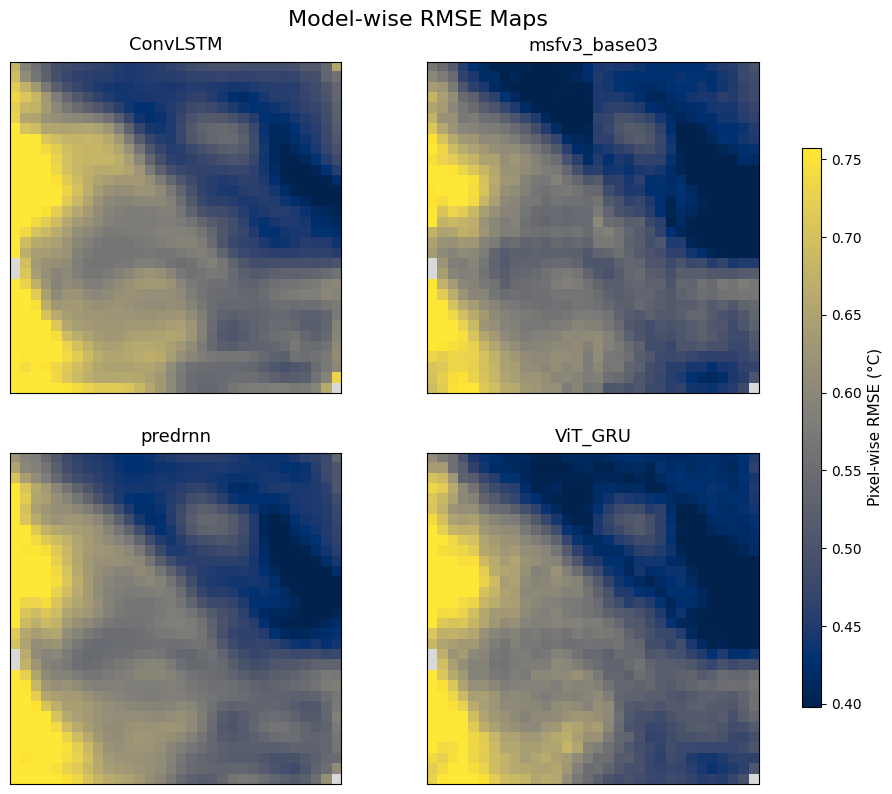

Saved: model_error_maps_rmse.png


In [18]:
# =========================================================
# 실행
# =========================================================
gt = np.load(GT_PATH)
mask = np.load(MASK_PATH)
preds_dict = load_saved_predictions(MODEL_NAMES)

print("GT shape:", gt.shape)
for k, v in preds_dict.items():
    print(f"{k}: {v.shape}")

error_maps = plot_error_maps(
    preds_dict=preds_dict,
    gt=gt,
    mask=mask,
    metric="rmse",      # "mae", "rmse", "bias"
    save_fig=SAVE_FIG,
    out_fig=OUT_FIG
)

if SAVE_FIG:
    print(f"Saved: {OUT_FIG}")

GT shape: (1792, 7, 1, 32, 32)
Mask shape: (32, 32)
ConvLSTM: (1792, 7, 1, 32, 32)
msfv3_gdl03: (1792, 7, 1, 32, 32)
predrnn: (1792, 7, 1, 32, 32)
ViT_GRU: (1792, 7, 1, 32, 32)

Season counts:
Winter: 2919
Spring: 3220
Summer: 3220
Autumn: 3185


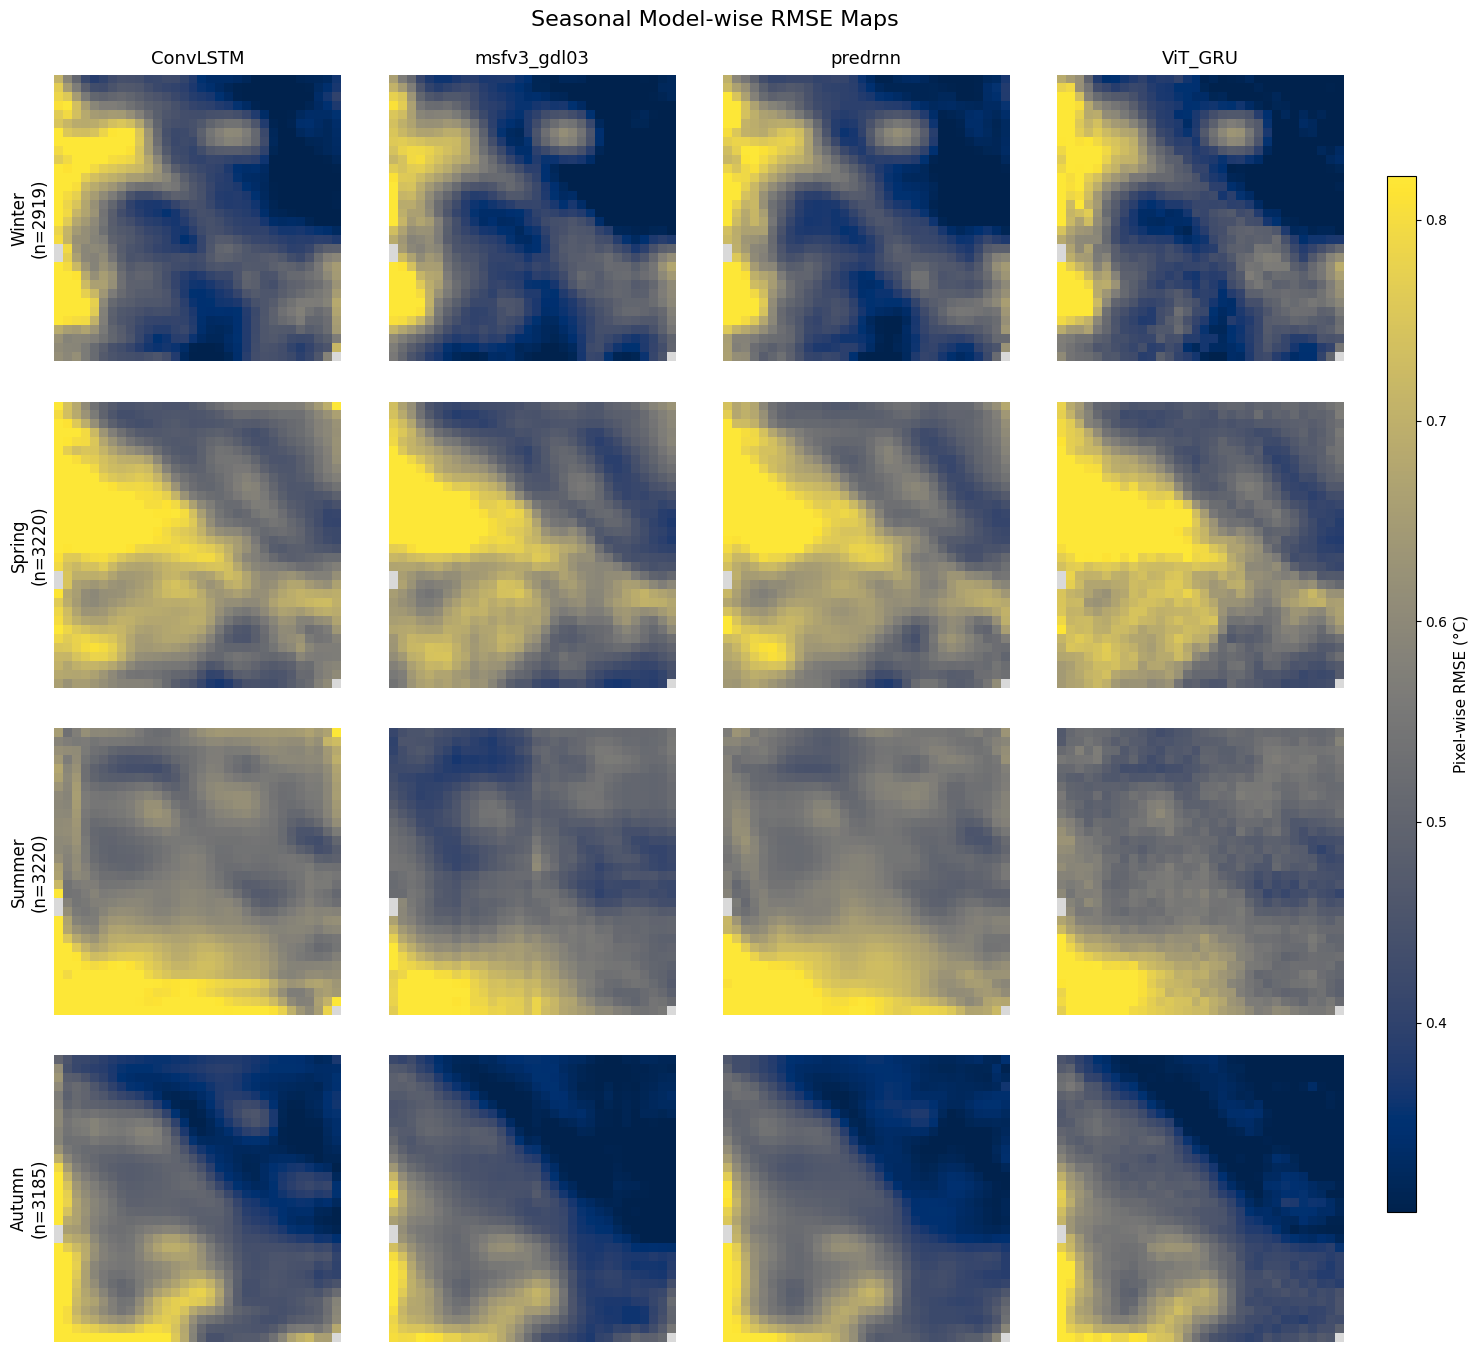

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# 설정
# =========================================================
MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

GT_PATH = "model_comparison/ground_truth.npy"
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"
PRED_DIR = "model_comparison"

MODEL_NAMES = [
    "ConvLSTM",
    "msfv3_gdl03",
    "predrnn",
    "ViT_GRU",
]

START_DATE = "2021-01-01"  # 전체 시계열 첫 날짜 기준
DATE_FREQ = "D"            # 일 단위
TIN = 14                   # 입력 길이

METRIC = "rmse"            # "mae", "rmse", "bias"
SAVE_FIG = False
OUT_FIG = f"seasonal_model_error_maps_{METRIC}.png"

MASK_COLOR = "#D9D9D9"
INTERP_MODE = "nearest"

CMAP_SEQ = "cividis"
CMAP_DIV = "coolwarm"


# =========================================================
# 유틸
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def load_saved_predictions(model_names, pred_dir=PRED_DIR):
    preds_dict = {}
    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if os.path.exists(path):
            preds_dict[name] = np.load(path)
        else:
            print(f"[WARN] Missing file: {path}")
    return preds_dict


def apply_mask_nan(field, mask):
    out = np.asarray(field).copy()
    mask = np.asarray(mask)
    if mask.ndim > 2:
        mask = np.squeeze(mask)
    out[mask <= 0] = np.nan
    return out


def to_nt_hw(arr):
    """
    arr:
      - (N, T, C, H, W)
      - (N, T, H, W)
    return:
      - (N, T, H, W)
    """
    arr = np.asarray(arr)
    if arr.ndim == 5:
        return arr[:, :, 0, :, :]
    elif arr.ndim == 4:
        return arr
    else:
        raise ValueError(f"Unsupported shape: {arr.shape}")


def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        raise ValueError(f"Invalid month: {month}")


def build_target_date_table(n_samples, tout, start_date=START_DATE, tin=TIN):
    """
    sample i, lead t 에 대응하는 target 날짜
    target date = 전체 시작일 + (i + tin + t) day
    """
    base = pd.to_datetime(start_date)
    date_table = np.empty((n_samples, tout), dtype="datetime64[ns]")

    for i in range(n_samples):
        for t in range(tout):
            date_table[i, t] = base + pd.to_timedelta(i + tin + t, unit="D")

    return pd.to_datetime(date_table.ravel()).values.reshape(n_samples, tout)


def compute_seasonal_error_maps(
    preds_dict,
    gt,
    mask,
    metric="rmse",
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
):
    """
    계절별 spatial error map 계산

    반환:
      seasonal_error_maps = {
        "Winter": {model_name: (H, W), ...},
        "Spring": {...},
        "Summer": {...},
        "Autumn": {...},
      }

      season_counts = {
        "Winter": int,
        "Spring": int,
        "Summer": int,
        "Autumn": int,
      }
    """
    seasons = ["Winter", "Spring", "Summer", "Autumn"]

    gt2 = to_nt_hw(gt)
    if denorm:
        gt2 = denorm_sst(gt2, mean=mean, std=std)

    N, T, H, W = gt2.shape

    target_dates = build_target_date_table(
        n_samples=N,
        tout=T,
        start_date=start_date,
        tin=tin,
    )

    season_table = np.empty((N, T), dtype=object)
    for i in range(N):
        for t in range(T):
            season_table[i, t] = month_to_season(pd.Timestamp(target_dates[i, t]).month)

    seasonal_error_maps = {s: {} for s in seasons}
    season_counts = {s: int(np.sum(season_table == s)) for s in seasons}

    for model_name, pred in preds_dict.items():
        pred2 = to_nt_hw(pred)

        if pred2.shape != gt2.shape:
            raise ValueError(
                f"Shape mismatch for {model_name}: pred={pred2.shape}, gt={gt2.shape}"
            )

        if denorm:
            pred2 = denorm_sst(pred2, mean=mean, std=std)

        err = pred2 - gt2  # (N, T, H, W)

        for season in seasons:
            season_mask = (season_table == season)       # (N, T)
            season_mask_4d = season_mask[:, :, None, None]  # (N, T, 1, 1)

            if metric == "mae":
                selected = np.where(season_mask_4d, np.abs(err), np.nan)
                err_map = np.nanmean(selected, axis=(0, 1))
            elif metric == "rmse":
                selected = np.where(season_mask_4d, err ** 2, np.nan)
                err_map = np.sqrt(np.nanmean(selected, axis=(0, 1)))
            elif metric == "bias":
                selected = np.where(season_mask_4d, err, np.nan)
                err_map = np.nanmean(selected, axis=(0, 1))
            else:
                raise ValueError(f"Unsupported metric: {metric}")

            err_map = apply_mask_nan(err_map, mask)
            seasonal_error_maps[season][model_name] = err_map

    return seasonal_error_maps, season_counts


def plot_seasonal_error_maps(
    seasonal_error_maps,
    season_counts,
    metric="rmse",
    cmap_seq="cividis",
    cmap_div="coolwarm",
    mask_color="#D9D9D9",
    interpolation="nearest",
    save_fig=False,
    out_fig="seasonal_model_error_maps.png",
):
    seasons = ["Winter", "Spring", "Summer", "Autumn"]

    model_names = []
    for season in seasons:
        if len(seasonal_error_maps[season]) > 0:
            model_names = list(seasonal_error_maps[season].keys())
            break

    if len(model_names) == 0:
        raise ValueError("No model maps found.")

    valid_vals = []
    for season in seasons:
        for model_name in model_names:
            m = seasonal_error_maps[season].get(model_name, None)
            if m is not None:
                vals = m[np.isfinite(m)]
                if vals.size > 0:
                    valid_vals.append(vals)

    if len(valid_vals) == 0:
        raise ValueError("No valid seasonal error maps found.")

    valid_vals = np.concatenate(valid_vals)

    if metric == "bias":
        vmax = np.nanpercentile(np.abs(valid_vals), 95)
        vmin = -vmax
        cmap = mpl.colormaps[cmap_div].copy()
    else:
        vmin = np.nanpercentile(valid_vals, 5)
        vmax = np.nanpercentile(valid_vals, 95)
        cmap = mpl.colormaps[cmap_seq].copy()

    cmap.set_bad(mask_color)

    nrows = len(seasons)
    ncols = len(model_names)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 3.6 * nrows),
        constrained_layout=False,
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    im = None
    for i, season in enumerate(seasons):
        for j, model_name in enumerate(model_names):
            ax = axes[i, j]
            m = seasonal_error_maps[season].get(model_name, None)

            if m is None:
                ax.axis("off")
                continue

            im = ax.imshow(
                m,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation=interpolation,
            )

            if i == 0:
                ax.set_title(model_name, fontsize=13, pad=8)

            if j == 0:
                ax.set_ylabel(f"{season}\n(n={season_counts[season]})", fontsize=12)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor(mask_color)

            for spine in ax.spines.values():
                spine.set_visible(False)

    fig.subplots_adjust(
        left=0.08,
        right=0.90,
        bottom=0.05,
        top=0.93,
        wspace=0.08,
        hspace=0.14,
    )

    cax = fig.add_axes([0.92, 0.14, 0.018, 0.72])
    cbar = fig.colorbar(im, cax=cax)

    if metric == "mae":
        cbar.set_label("Pixel-wise MAE (°C)", fontsize=11)
        fig.suptitle("Seasonal Model-wise MAE Maps", fontsize=16, y=0.975)
    elif metric == "rmse":
        cbar.set_label("Pixel-wise RMSE (°C)", fontsize=11)
        fig.suptitle("Seasonal Model-wise RMSE Maps", fontsize=16, y=0.975)
    elif metric == "bias":
        cbar.set_label("Pixel-wise Bias (Pred - GT, °C)", fontsize=11)
        fig.suptitle("Seasonal Model-wise Bias Maps", fontsize=16, y=0.975)

    if save_fig:
        plt.savefig(out_fig, dpi=220, bbox_inches="tight")

    plt.show()


# =========================================================
# 실행
# =========================================================
gt = np.load(GT_PATH)
mask = np.load(MASK_PATH)
preds_dict = load_saved_predictions(MODEL_NAMES)

print("GT shape:", gt.shape)
print("Mask shape:", np.asarray(mask).shape)
for k, v in preds_dict.items():
    print(f"{k}: {v.shape}")

seasonal_error_maps, season_counts = compute_seasonal_error_maps(
    preds_dict=preds_dict,
    gt=gt,
    mask=mask,
    metric=METRIC,
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
)

print("\nSeason counts:")
for season, cnt in season_counts.items():
    print(f"{season}: {cnt}")

plot_seasonal_error_maps(
    seasonal_error_maps=seasonal_error_maps,
    season_counts=season_counts,
    metric=METRIC,
    cmap_seq=CMAP_SEQ,
    cmap_div=CMAP_DIV,
    mask_color=MASK_COLOR,
    interpolation=INTERP_MODE,
    save_fig=SAVE_FIG,
    out_fig=OUT_FIG,
)

if SAVE_FIG:
    print(f"\nSaved: {OUT_FIG}")

GT shape: (1792, 7, 1, 32, 32)
ConvLSTM: (1792, 7, 1, 32, 32)
msfv3_gdl03: (1792, 7, 1, 32, 32)
predrnn: (1792, 7, 1, 32, 32)
ViT_GRU: (1792, 7, 1, 32, 32)


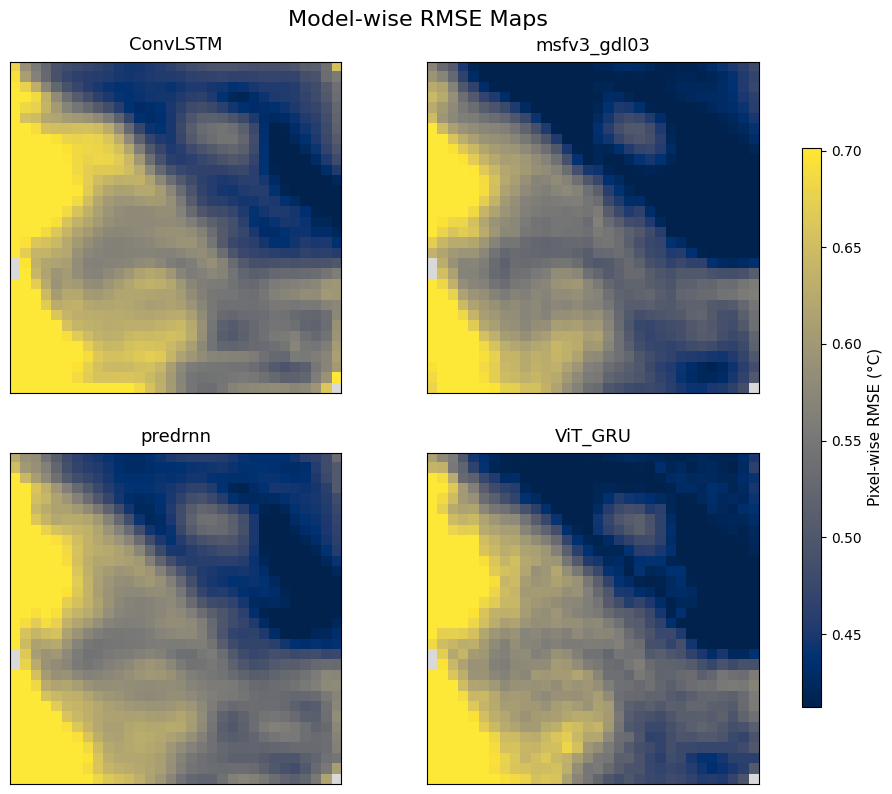

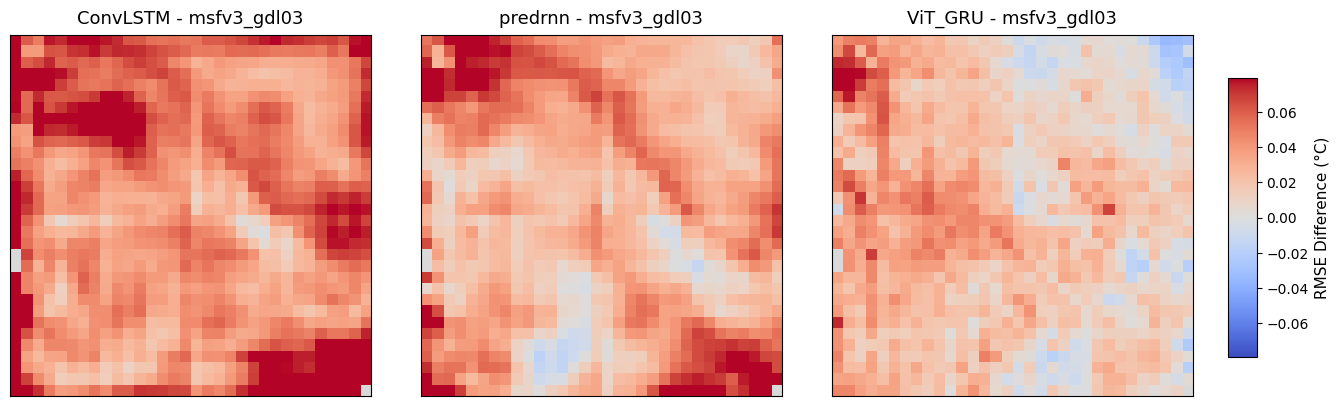

In [20]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# 설정
# =========================================================
MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

GT_PATH = "model_comparison/ground_truth.npy"
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"
PRED_DIR = "model_comparison"

MODEL_NAMES = [
    "ConvLSTM",
    "msfv3_gdl03",   # 기준 모델(ours)
    "predrnn",
    "ViT_GRU",
]

REF_MODEL = "msfv3_gdl03"   # 차이맵 기준 모델
METRIC = "rmse"             # "mae", "rmse", "bias"

SAVE_FIG = False
OUT_FIG_ABS = f"model_error_maps_{METRIC}.png"
OUT_FIG_DIFF = f"model_error_diff_maps_vs_{REF_MODEL}_{METRIC}.png"

MASK_COLOR = "#D9D9D9"
INTERP_MODE = "nearest"

# 절대 오차맵 컬러맵
CMAP_SEQ = "cividis"
CMAP_DIV = "coolwarm"

# contrast를 조금 더 보이게 하려면 percentile 범위를 타이트하게
ABS_VMIN_Q = 10
ABS_VMAX_Q = 90
DIFF_VMAX_Q = 95


# =========================================================
# 유틸
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def load_saved_predictions(model_names, pred_dir=PRED_DIR):
    preds_dict = {}
    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if os.path.exists(path):
            preds_dict[name] = np.load(path)
        else:
            print(f"[WARN] Missing file: {path}")
    return preds_dict


def apply_mask_nan(field, mask):
    out = np.asarray(field).copy()
    out[np.asarray(mask) <= 0] = np.nan
    return out


def compute_pixel_error_map(pred, gt, metric="mae", denorm=True, mean=MEAN_SST, std=STD_SST):
    """
    pred, gt:
      - (N, T, C, H, W)
      - (N, T, H, W)
    return:
      - (H, W)
    """
    pred = np.asarray(pred)
    gt = np.asarray(gt)

    if pred.shape != gt.shape:
        raise ValueError(f"Shape mismatch: pred={pred.shape}, gt={gt.shape}")

    if pred.ndim == 5:
        pred2 = pred[:, :, 0, :, :]
        gt2 = gt[:, :, 0, :, :]
    elif pred.ndim == 4:
        pred2 = pred
        gt2 = gt
    else:
        raise ValueError(f"Unsupported shape: {pred.shape}")

    if denorm:
        pred2 = denorm_sst(pred2, mean=mean, std=std)
        gt2 = denorm_sst(gt2, mean=mean, std=std)

    err = pred2 - gt2  # (N, T, H, W)

    if metric == "mae":
        out = np.nanmean(np.abs(err), axis=(0, 1))
    elif metric == "rmse":
        out = np.sqrt(np.nanmean(err ** 2, axis=(0, 1)))
    elif metric == "bias":
        out = np.nanmean(err, axis=(0, 1))
    else:
        raise ValueError(f"Unsupported metric: {metric}")

    return out


# =========================================================
# 절대 오차맵
# =========================================================
def build_error_maps(preds_dict, gt, mask, metric="mae"):
    error_maps = {}
    for model_name, pred in preds_dict.items():
        err_map = compute_pixel_error_map(pred, gt, metric=metric, denorm=True)
        err_map = apply_mask_nan(err_map, mask)
        error_maps[model_name] = err_map
    return error_maps


def plot_error_maps(
    error_maps,
    metric="mae",
    cmap_seq=CMAP_SEQ,
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=False,
    out_fig="error_maps.png"
):
    all_vals = np.concatenate([
        m[np.isfinite(m)].ravel() for m in error_maps.values()
    ])

    if metric == "bias":
        vmax = np.nanpercentile(np.abs(all_vals), DIFF_VMAX_Q)
        vmin = -vmax
        cmap = mpl.colormaps[cmap_div].copy()
    else:
        vmin = np.nanpercentile(all_vals, ABS_VMIN_Q)
        vmax = np.nanpercentile(all_vals, ABS_VMAX_Q)
        cmap = mpl.colormaps[cmap_seq].copy()

    cmap.set_bad(MASK_COLOR)

    model_names = list(error_maps.keys())
    n = len(model_names)

    if n == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, n)
        nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.8 * ncols, 4.3 * nrows),
        constrained_layout=False
    )
    axes = np.array(axes).reshape(-1)

    im = None
    for ax, model_name in zip(axes, model_names):
        im = ax.imshow(
            error_maps[model_name],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation=interpolation
        )
        ax.set_title(model_name, fontsize=13, pad=8)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor(MASK_COLOR)

    for ax in axes[len(model_names):]:
        ax.axis("off")

    fig.subplots_adjust(
        left=0.05, right=0.88,
        bottom=0.06, top=0.90,
        wspace=0.10, hspace=0.18
    )
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.65])
    cbar = fig.colorbar(im, cax=cax)

    if metric == "mae":
        cbar.set_label("Pixel-wise MAE (°C)", fontsize=11)
        fig.suptitle("Model-wise Mean Absolute Error Maps", fontsize=16, y=0.96)
    elif metric == "rmse":
        cbar.set_label("Pixel-wise RMSE (°C)", fontsize=11)
        fig.suptitle("Model-wise RMSE Maps", fontsize=16, y=0.96)
    elif metric == "bias":
        cbar.set_label("Pixel-wise Bias (Pred - GT, °C)", fontsize=11)
        fig.suptitle("Model-wise Bias Maps", fontsize=16, y=0.96)

    if save_fig:
        plt.savefig(out_fig, dpi=220, bbox_inches="tight")

    plt.show()


# =========================================================
# 차이맵: baseline_error - ref_error
# 양수(빨강) = baseline이 ref보다 더 나쁨 = ref가 더 좋음
# 음수(파랑) = baseline이 ref보다 더 좋음
# =========================================================
def build_difference_maps(error_maps, ref_model):
    if ref_model not in error_maps:
        raise ValueError(f"Reference model '{ref_model}' not found in error_maps")

    ref_map = error_maps[ref_model]
    diff_maps = {}

    for model_name, err_map in error_maps.items():
        if model_name == ref_model:
            continue
        diff_map = err_map - ref_map
        diff_maps[model_name] = diff_map

    return diff_maps

def plot_difference_maps(
    diff_maps,
    ref_model,
    metric="mae",
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=False,
    out_fig="difference_maps.png"
):
    all_vals = np.concatenate([
        m[np.isfinite(m)].ravel() for m in diff_maps.values()
    ])

    vmax = np.nanpercentile(np.abs(all_vals), DIFF_VMAX_Q)
    vmin = -vmax

    cmap = mpl.colormaps[cmap_div].copy()
    cmap.set_bad(MASK_COLOR)

    model_names = list(diff_maps.keys())
    n = len(model_names)

    if n == 3:
        nrows, ncols = 1, 3
    elif n == 4:
        nrows, ncols = 2, 2
    else:
        ncols = min(3, n)
        nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.8 * ncols, 4.3 * nrows),
        constrained_layout=False
    )
    axes = np.array(axes).reshape(-1)

    im = None
    for ax, model_name in zip(axes, model_names):
        im = ax.imshow(
            diff_maps[model_name],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation=interpolation
        )

        # 패널 제목: 비교모델 - 내모델
        ax.set_title(f"{model_name} - {ref_model}", fontsize=13, pad=8)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor(MASK_COLOR)

    for ax in axes[len(model_names):]:
        ax.axis("off")

    fig.subplots_adjust(
        left=0.05, right=0.88,
        bottom=0.06, top=0.90,
        wspace=0.10, hspace=0.18
    )

    cax = fig.add_axes([0.90, 0.15, 0.02, 0.65])
    cbar = fig.colorbar(im, cax=cax)

    if metric == "mae":
        cbar.set_label("MAE Difference (°C)", fontsize=11)
    elif metric == "rmse":
        cbar.set_label("RMSE Difference (°C)", fontsize=11)
    elif metric == "bias":
        cbar.set_label("Bias Difference (°C)", fontsize=11)

    # 전체 suptitle 제거
    # fig.suptitle(...)

    if save_fig:
        plt.savefig(out_fig, dpi=220, bbox_inches="tight")

    plt.show()

# =========================================================
# 실행
# =========================================================
gt = np.load(GT_PATH)
mask = np.load(MASK_PATH)
preds_dict = load_saved_predictions(MODEL_NAMES)

print("GT shape:", gt.shape)
for k, v in preds_dict.items():
    print(f"{k}: {v.shape}")

# 1) 절대 오차맵
error_maps = build_error_maps(
    preds_dict=preds_dict,
    gt=gt,
    mask=mask,
    metric=METRIC
)

plot_error_maps(
    error_maps=error_maps,
    metric=METRIC,
    save_fig=SAVE_FIG,
    out_fig=OUT_FIG_ABS
)

# 2) 기준 모델 대비 차이맵
diff_maps = build_difference_maps(
    error_maps=error_maps,
    ref_model=REF_MODEL
)

plot_difference_maps(
    diff_maps=diff_maps,
    ref_model=REF_MODEL,
    metric=METRIC,
    save_fig=SAVE_FIG,
    out_fig=OUT_FIG_DIFF
)

if SAVE_FIG:
    print(f"Saved: {OUT_FIG_ABS}")
    print(f"Saved: {OUT_FIG_DIFF}")

GT shape: (1792, 7, 1, 32, 32)
Mask shape: (32, 32)
ConvLSTM: (1792, 7, 1, 32, 32)
msfv3_gdl03: (1792, 7, 1, 32, 32)
predrnn: (1792, 7, 1, 32, 32)
ViT_GRU: (1792, 7, 1, 32, 32)

Group counts:
Overall: 12544
Winter: 2919
Spring: 3220
Summer: 3220
Autumn: 3185


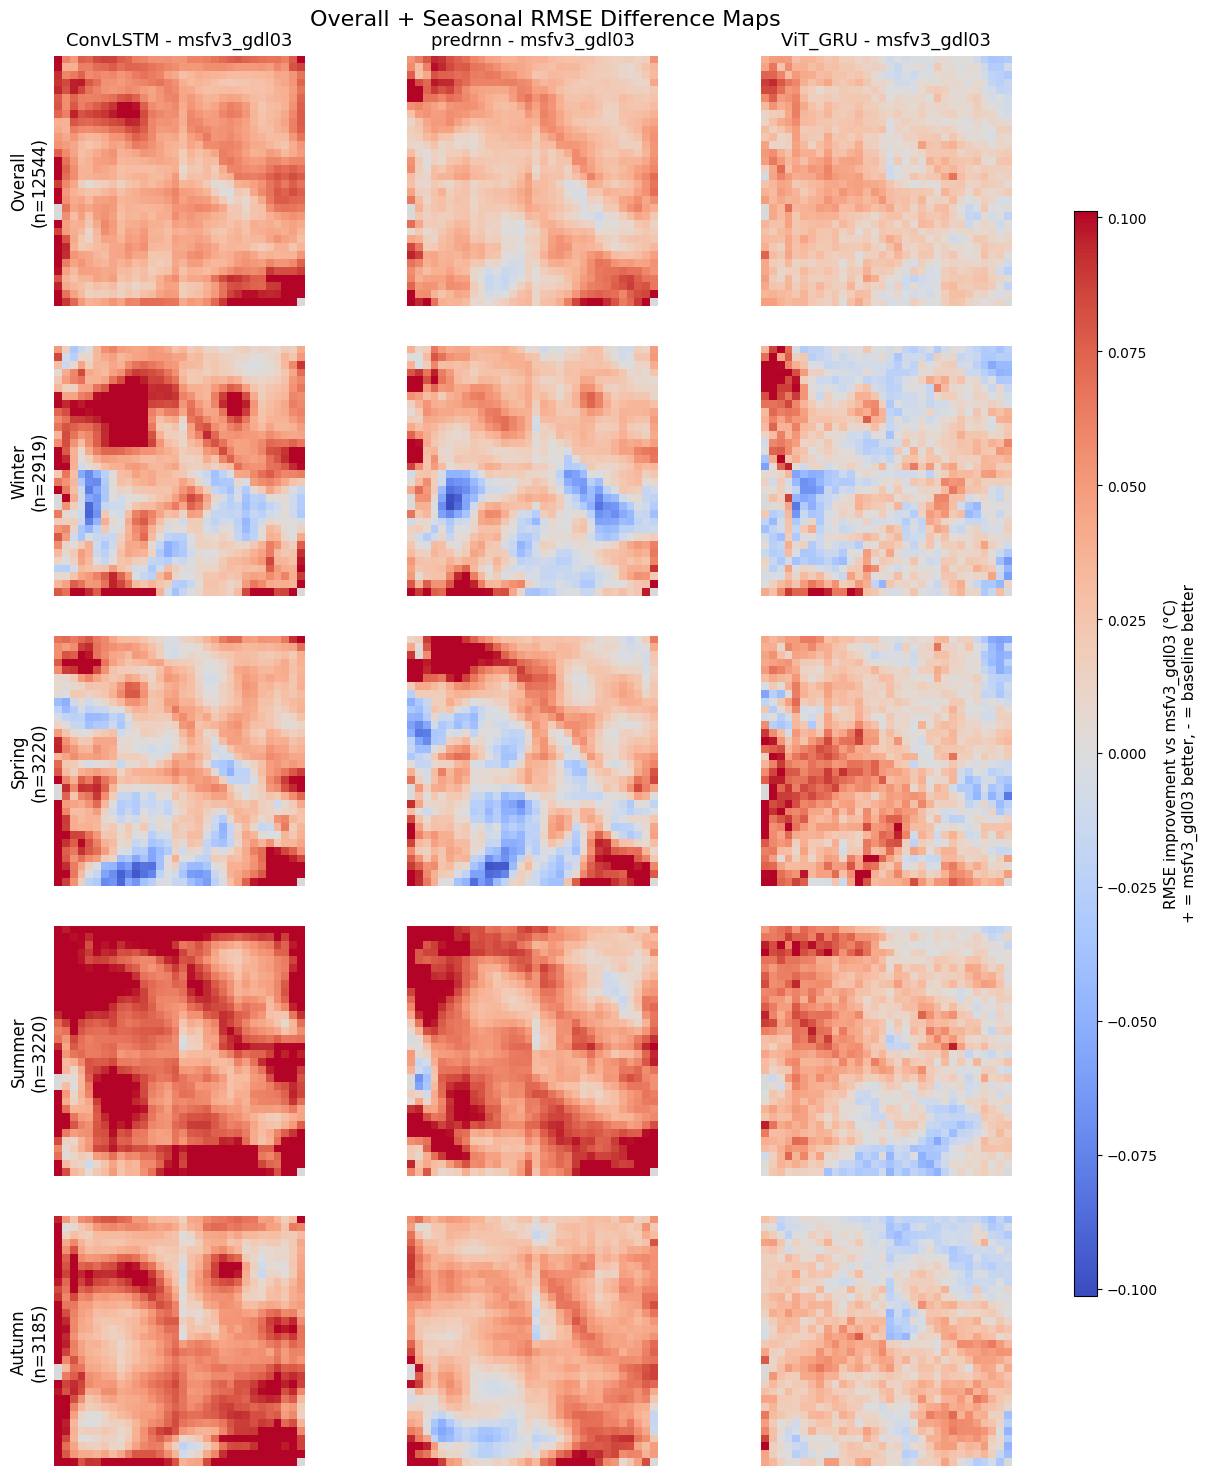

In [21]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# 설정
# =========================================================
MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

GT_PATH = "model_comparison/ground_truth.npy"
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"
PRED_DIR = "model_comparison"

MODEL_NAMES = [
    "ConvLSTM",
    "msfv3_gdl03",   # ours
    "predrnn",
    "ViT_GRU",
]

REF_MODEL = "msfv3_gdl03"   # 기준 모델(ours)

START_DATE = "2021-01-15"   # 전체 시계열 시작일
TIN = 14                    # 입력 길이
DATE_FREQ = "D"

METRIC = "rmse"             # "mae", "rmse", "bias"

SAVE_FIG = False
OUT_FIG = f"overall_seasonal_diff_maps_vs_{REF_MODEL}_{METRIC}.png"

MASK_COLOR = "#D9D9D9"
INTERP_MODE = "nearest"
CMAP_DIV = "coolwarm"

DIFF_VMAX_Q = 95
DIFF_TITLE_STYLE = "minus"  # "minus" or "vs"

SEASONS = ["Overall", "Winter", "Spring", "Summer", "Autumn"]


# =========================================================
# 유틸
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def load_saved_predictions(model_names, pred_dir=PRED_DIR):
    preds_dict = {}
    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if os.path.exists(path):
            preds_dict[name] = np.load(path)
        else:
            print(f"[WARN] Missing file: {path}")
    return preds_dict


def apply_mask_nan(field, mask):
    out = np.asarray(field, dtype=np.float64).copy()
    mask = np.asarray(mask)
    if mask.ndim > 2:
        mask = np.squeeze(mask)
    out[mask <= 0] = np.nan
    return out


def to_nt_hw(arr):
    """
    arr:
      - (N, T, C, H, W)
      - (N, T, H, W)
    return:
      - (N, T, H, W)
    """
    arr = np.asarray(arr)
    if arr.ndim == 5:
        return arr[:, :, 0, :, :]
    elif arr.ndim == 4:
        return arr
    else:
        raise ValueError(f"Unsupported shape: {arr.shape}")


def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        raise ValueError(f"Invalid month: {month}")


def build_target_date_table(n_samples, tout, start_date=START_DATE, tin=TIN):
    """
    sample i, lead t 에 대응하는 target 날짜
    target date = 전체 시작일 + (i + tin + t) day
    """
    base = pd.to_datetime(start_date)
    date_table = np.empty((n_samples, tout), dtype="datetime64[ns]")

    for i in range(n_samples):
        for t in range(tout):
            date_table[i, t] = base + pd.to_timedelta(i + tin + t, unit="D")

    return pd.to_datetime(date_table.ravel()).values.reshape(n_samples, tout)


def build_season_table(n_samples, tout, start_date=START_DATE, tin=TIN):
    target_dates = build_target_date_table(
        n_samples=n_samples,
        tout=tout,
        start_date=start_date,
        tin=tin,
    )

    season_table = np.empty((n_samples, tout), dtype=object)
    for i in range(n_samples):
        for t in range(tout):
            season_table[i, t] = month_to_season(pd.Timestamp(target_dates[i, t]).month)
    return season_table


def compute_pixel_error_map_from_err(err, metric="rmse"):
    """
    err: (N, T, H, W)
    return: (H, W)
    """
    if metric == "mae":
        return np.nanmean(np.abs(err), axis=(0, 1))
    elif metric == "rmse":
        return np.sqrt(np.nanmean(err ** 2, axis=(0, 1)))
    elif metric == "bias":
        return np.nanmean(err, axis=(0, 1))
    else:
        raise ValueError(f"Unsupported metric: {metric}")


def compute_pixel_error_map_from_err_with_mask(err, valid_nt, metric="rmse"):
    """
    err: (N, T, H, W)
    valid_nt: (N, T) boolean
    return: (H, W)
    """
    valid_nt = np.asarray(valid_nt, dtype=bool)
    valid_4d = valid_nt[:, :, None, None]

    if metric == "mae":
        selected = np.where(valid_4d, np.abs(err), np.nan)
        return np.nanmean(selected, axis=(0, 1))
    elif metric == "rmse":
        selected = np.where(valid_4d, err ** 2, np.nan)
        return np.sqrt(np.nanmean(selected, axis=(0, 1)))
    elif metric == "bias":
        selected = np.where(valid_4d, err, np.nan)
        return np.nanmean(selected, axis=(0, 1))
    else:
        raise ValueError(f"Unsupported metric: {metric}")


def _safe_concat_finite(map_dict):
    vals = []
    for arr in map_dict.values():
        arr = np.asarray(arr)
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite.ravel())
    if len(vals) == 0:
        raise ValueError("No finite values found for plotting.")
    return np.concatenate(vals)


def _get_diff_panel_title(model_name, ref_model, style="minus"):
    if style == "vs":
        return f"{model_name} vs {ref_model}"
    return f"{model_name} - {ref_model}"


# =========================================================
# 오차맵 계산
# =========================================================
def compute_overall_and_seasonal_error_maps(
    preds_dict,
    gt,
    mask,
    metric="rmse",
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
):
    """
    반환:
      error_maps_by_group = {
        "Overall": {model: (H,W), ...},
        "Winter":  {model: (H,W), ...},
        "Spring":  {model: (H,W), ...},
        "Summer":  {model: (H,W), ...},
        "Autumn":  {model: (H,W), ...},
      }

      group_counts = {
        "Overall": int,
        "Winter": int,
        "Spring": int,
        "Summer": int,
        "Autumn": int,
      }
    """
    gt2 = to_nt_hw(gt)
    if denorm:
        gt2 = denorm_sst(gt2, mean=mean, std=std)

    N, T, H, W = gt2.shape
    season_table = build_season_table(
        n_samples=N,
        tout=T,
        start_date=start_date,
        tin=tin,
    )

    error_maps_by_group = {g: {} for g in SEASONS}
    group_counts = {
        "Overall": int(N * T),
        "Winter": int(np.sum(season_table == "Winter")),
        "Spring": int(np.sum(season_table == "Spring")),
        "Summer": int(np.sum(season_table == "Summer")),
        "Autumn": int(np.sum(season_table == "Autumn")),
    }

    for model_name, pred in preds_dict.items():
        pred2 = to_nt_hw(pred)

        if pred2.shape != gt2.shape:
            raise ValueError(
                f"Shape mismatch for {model_name}: pred={pred2.shape}, gt={gt2.shape}"
            )

        if denorm:
            pred2 = denorm_sst(pred2, mean=mean, std=std)

        err = pred2 - gt2  # (N, T, H, W)

        # Overall
        overall_map = compute_pixel_error_map_from_err(err, metric=metric)
        error_maps_by_group["Overall"][model_name] = apply_mask_nan(overall_map, mask)

        # Seasonal
        for season in ["Winter", "Spring", "Summer", "Autumn"]:
            season_mask = (season_table == season)
            season_map = compute_pixel_error_map_from_err_with_mask(
                err, valid_nt=season_mask, metric=metric
            )
            error_maps_by_group[season][model_name] = apply_mask_nan(season_map, mask)

    return error_maps_by_group, group_counts


def build_difference_maps_by_group(error_maps_by_group, ref_model):
    """
    반환:
      diff_maps_by_group = {
        "Overall": {baseline_model: baseline_err - ref_err, ...},
        "Winter": {...},
        ...
      }
    """
    diff_maps_by_group = {}

    for group_name, model_map_dict in error_maps_by_group.items():
        if ref_model not in model_map_dict:
            raise ValueError(f"Reference model '{ref_model}' not found in group '{group_name}'")

        ref_map = model_map_dict[ref_model]
        diff_maps_by_group[group_name] = {}

        for model_name, err_map in model_map_dict.items():
            if model_name == ref_model:
                continue
            diff_maps_by_group[group_name][model_name] = err_map - ref_map

    return diff_maps_by_group


# =========================================================
# 시각화
# =========================================================
def plot_overall_and_seasonal_difference_maps(
    diff_maps_by_group,
    group_counts,
    ref_model,
    metric="rmse",
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=False,
    out_fig="overall_seasonal_difference_maps.png",
    title_style=DIFF_TITLE_STYLE,
    mask_color=MASK_COLOR,
):
    row_names = SEASONS

    model_names = []
    for group_name in row_names:
        if group_name in diff_maps_by_group and len(diff_maps_by_group[group_name]) > 0:
            model_names = list(diff_maps_by_group[group_name].keys())
            break

    if len(model_names) == 0:
        raise ValueError("No difference maps found.")

    valid_vals = []
    for group_name in row_names:
        for model_name in model_names:
            m = diff_maps_by_group.get(group_name, {}).get(model_name, None)
            if m is not None:
                vals = m[np.isfinite(m)]
                if vals.size > 0:
                    valid_vals.append(vals)

    if len(valid_vals) == 0:
        raise ValueError("No valid difference maps found.")

    valid_vals = np.concatenate(valid_vals)
    vmax = np.nanpercentile(np.abs(valid_vals), DIFF_VMAX_Q)
    vmax = max(vmax, 1e-8)
    vmin = -vmax

    cmap = mpl.colormaps[cmap_div].copy()
    cmap.set_bad(mask_color)

    nrows = len(row_names)
    ncols = len(model_names)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 3.1 * nrows),
        constrained_layout=False,
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    im = None
    for i, group_name in enumerate(row_names):
        for j, model_name in enumerate(model_names):
            ax = axes[i, j]
            m = diff_maps_by_group.get(group_name, {}).get(model_name, None)

            if m is None:
                ax.axis("off")
                continue

            im = ax.imshow(
                m,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation=interpolation,
            )

            if i == 0:
                ax.set_title(
                    _get_diff_panel_title(model_name, ref_model, style=title_style),
                    fontsize=13,
                    pad=8,
                )

            if j == 0:
                ax.set_ylabel(f"{group_name}\n(n={group_counts[group_name]})", fontsize=12)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor(mask_color)

            for spine in ax.spines.values():
                spine.set_visible(False)

    fig.subplots_adjust(
        left=0.08,
        right=0.90,
        bottom=0.04,
        top=0.95,
        wspace=0.08,
        hspace=0.16,
    )

    cax = fig.add_axes([0.92, 0.15, 0.018, 0.70])
    cbar = fig.colorbar(im, cax=cax)

    if metric == "mae":
        cbar.set_label(
            f"MAE improvement vs {ref_model} (°C)\n"
            f"+ = {ref_model} better, - = baseline better",
            fontsize=11,
        )
        fig.suptitle("Overall + Seasonal MAE Difference Maps", fontsize=16, y=0.98)
    elif metric == "rmse":
        cbar.set_label(
            f"RMSE improvement vs {ref_model} (°C)\n"
            f"+ = {ref_model} better, - = baseline better",
            fontsize=11,
        )
        fig.suptitle("Overall + Seasonal RMSE Difference Maps", fontsize=16, y=0.98)
    elif metric == "bias":
        cbar.set_label(
            f"Bias difference vs {ref_model} (°C)\n"
            f"(baseline - {ref_model})",
            fontsize=11,
        )
        fig.suptitle("Overall + Seasonal Bias Difference Maps", fontsize=16, y=0.98)

    if save_fig:
        plt.savefig(out_fig, dpi=220, bbox_inches="tight")

    plt.show()


# =========================================================
# 실행
# =========================================================
gt = np.load(GT_PATH)
mask = np.load(MASK_PATH)
preds_dict = load_saved_predictions(MODEL_NAMES)

print("GT shape:", gt.shape)
print("Mask shape:", np.asarray(mask).shape)
for k, v in preds_dict.items():
    print(f"{k}: {v.shape}")

error_maps_by_group, group_counts = compute_overall_and_seasonal_error_maps(
    preds_dict=preds_dict,
    gt=gt,
    mask=mask,
    metric=METRIC,
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
)

print("\nGroup counts:")
for group_name in SEASONS:
    print(f"{group_name}: {group_counts[group_name]}")

diff_maps_by_group = build_difference_maps_by_group(
    error_maps_by_group=error_maps_by_group,
    ref_model=REF_MODEL,
)

plot_overall_and_seasonal_difference_maps(
    diff_maps_by_group=diff_maps_by_group,
    group_counts=group_counts,
    ref_model=REF_MODEL,
    metric=METRIC,
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=SAVE_FIG,
    out_fig=OUT_FIG,
    title_style=DIFF_TITLE_STYLE,
    mask_color=MASK_COLOR,
)

if SAVE_FIG:
    print(f"\nSaved: {OUT_FIG}")

GT shape: (1792, 7, 1, 32, 32)
Mask shape: (32, 32)
ConvLSTM: (1792, 7, 1, 32, 32)
msfv3_gdl03: (1792, 7, 1, 32, 32)
predrnn: (1792, 7, 1, 32, 32)
ViT_GRU: (1792, 7, 1, 32, 32)

Group counts:
Summer: 3220 (25.67%)
Autumn: 3185 (25.39%)


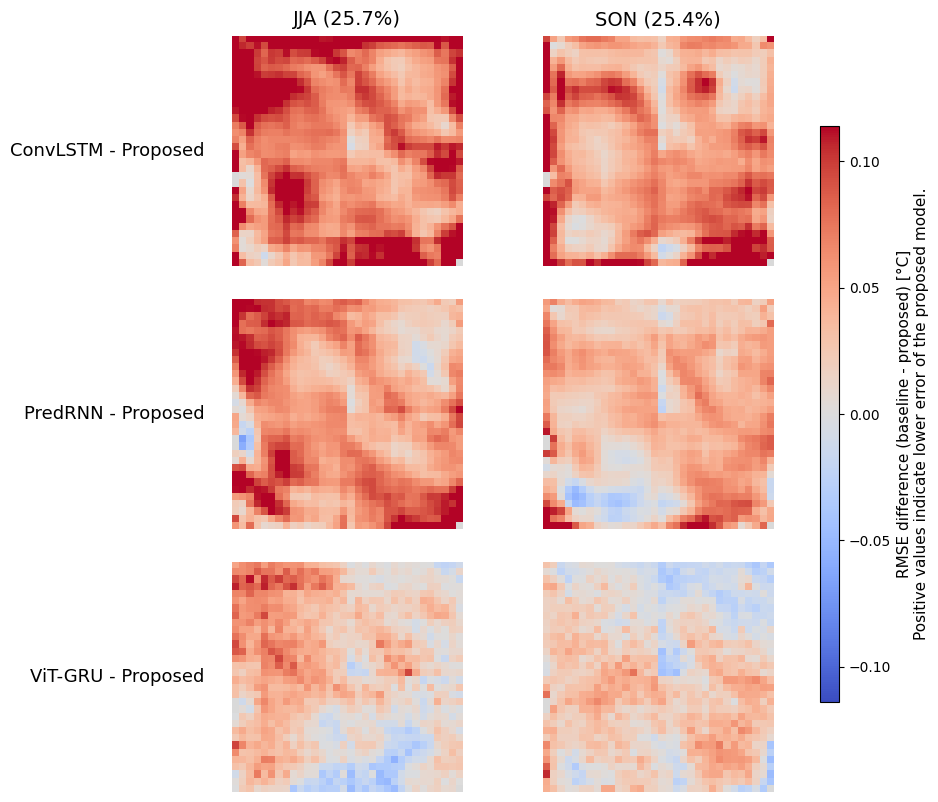

In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# Configuration
# =========================================================
MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

GT_PATH = "model_comparison/ground_truth.npy"
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"
PRED_DIR = "model_comparison"

MODEL_NAMES = [
    "ConvLSTM",
    "msfv3_gdl03",   # proposed model
    "predrnn",
    "ViT_GRU",
]

REF_MODEL = "msfv3_gdl03"

START_DATE = "2021-01-15"
TIN = 14
METRIC = "rmse"   # "mae", "rmse", "bias"

SAVE_FIG = False
OUT_FIG = f"jja_son_diff_maps_vs_{REF_MODEL}_{METRIC}.png"

MASK_COLOR = "#D9D9D9"
INTERP_MODE = "nearest"
CMAP_DIV = "coolwarm"
DIFF_VMAX_Q = 95

# 논문용: JJA / SON만 사용
SEASONS = ["Summer", "Autumn"]
SEASON_DISPLAY = {
    "Summer": "JJA",
    "Autumn": "SON",
}

MODEL_DISPLAY = {
    "ConvLSTM": "ConvLSTM - Proposed",
    "predrnn": "PredRNN - Proposed",
    "ViT_GRU": "ViT-GRU - Proposed",
}


# =========================================================
# Utilities
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def load_saved_predictions(model_names, pred_dir=PRED_DIR):
    preds_dict = {}
    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if os.path.exists(path):
            preds_dict[name] = np.load(path)
        else:
            print(f"[WARN] Missing file: {path}")
    return preds_dict


def apply_mask_nan(field, mask):
    out = np.asarray(field, dtype=np.float64).copy()
    mask = np.asarray(mask)
    if mask.ndim > 2:
        mask = np.squeeze(mask)
    out[mask <= 0] = np.nan
    return out


def to_nt_hw(arr):
    arr = np.asarray(arr)
    if arr.ndim == 5:
        return arr[:, :, 0, :, :]
    elif arr.ndim == 4:
        return arr
    else:
        raise ValueError(f"Unsupported shape: {arr.shape}")


def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        raise ValueError(f"Invalid month: {month}")


def build_target_date_table(n_samples, tout, start_date=START_DATE, tin=TIN):
    base = pd.to_datetime(start_date)
    date_table = np.empty((n_samples, tout), dtype="datetime64[ns]")

    for i in range(n_samples):
        for t in range(tout):
            date_table[i, t] = base + pd.to_timedelta(i + tin + t, unit="D")

    return pd.to_datetime(date_table.ravel()).values.reshape(n_samples, tout)


def build_season_table(n_samples, tout, start_date=START_DATE, tin=TIN):
    target_dates = build_target_date_table(
        n_samples=n_samples,
        tout=tout,
        start_date=start_date,
        tin=tin,
    )

    season_table = np.empty((n_samples, tout), dtype=object)
    for i in range(n_samples):
        for t in range(tout):
            season_table[i, t] = month_to_season(pd.Timestamp(target_dates[i, t]).month)
    return season_table


def compute_pixel_error_map_from_err_with_mask(err, valid_nt, metric="rmse"):
    valid_nt = np.asarray(valid_nt, dtype=bool)
    valid_4d = valid_nt[:, :, None, None]

    if metric == "mae":
        selected = np.where(valid_4d, np.abs(err), np.nan)
        return np.nanmean(selected, axis=(0, 1))
    elif metric == "rmse":
        selected = np.where(valid_4d, err ** 2, np.nan)
        return np.sqrt(np.nanmean(selected, axis=(0, 1)))
    elif metric == "bias":
        selected = np.where(valid_4d, err, np.nan)
        return np.nanmean(selected, axis=(0, 1))
    else:
        raise ValueError(f"Unsupported metric: {metric}")


# =========================================================
# Error map computation
# =========================================================
def compute_seasonal_error_maps(
    preds_dict,
    gt,
    mask,
    metric="rmse",
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
):
    gt2 = to_nt_hw(gt)
    if denorm:
        gt2 = denorm_sst(gt2, mean=mean, std=std)

    N, T, H, W = gt2.shape
    season_table = build_season_table(
        n_samples=N,
        tout=T,
        start_date=start_date,
        tin=tin,
    )

    error_maps_by_group = {g: {} for g in SEASONS}
    total_count = int(season_table.size)
    group_counts = {season: int(np.sum(season_table == season)) for season in SEASONS}
    group_percents = {season: 100.0 * group_counts[season] / total_count for season in SEASONS}

    for model_name, pred in preds_dict.items():
        pred2 = to_nt_hw(pred)

        if pred2.shape != gt2.shape:
            raise ValueError(
                f"Shape mismatch for {model_name}: pred={pred2.shape}, gt={gt2.shape}"
            )

        if denorm:
            pred2 = denorm_sst(pred2, mean=mean, std=std)

        err = pred2 - gt2

        for season in SEASONS:
            season_mask = (season_table == season)
            season_map = compute_pixel_error_map_from_err_with_mask(
                err, valid_nt=season_mask, metric=metric
            )
            error_maps_by_group[season][model_name] = apply_mask_nan(season_map, mask)

    return error_maps_by_group, group_counts, group_percents


def build_difference_maps_by_group(error_maps_by_group, ref_model):
    diff_maps_by_group = {}

    for group_name, model_map_dict in error_maps_by_group.items():
        if ref_model not in model_map_dict:
            raise ValueError(f"Reference model '{ref_model}' not found in group '{group_name}'")

        ref_map = model_map_dict[ref_model]
        diff_maps_by_group[group_name] = {}

        for model_name, err_map in model_map_dict.items():
            if model_name == ref_model:
                continue
            diff_maps_by_group[group_name][model_name] = err_map - ref_map

    return diff_maps_by_group


# =========================================================
# Visualization
#   - rows: baseline models
#   - cols: JJA / SON
#   - row labels: horizontal
#   - no figure title
# =========================================================
def plot_jja_son_difference_maps(
    diff_maps_by_group,
    group_percents,
    ref_model,
    metric="rmse",
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=False,
    out_fig="jja_son_difference_maps.png",
    mask_color=MASK_COLOR,
):
    col_names = SEASONS

    model_names = []
    for group_name in col_names:
        if group_name in diff_maps_by_group and len(diff_maps_by_group[group_name]) > 0:
            model_names = list(diff_maps_by_group[group_name].keys())
            break

    if len(model_names) == 0:
        raise ValueError("No difference maps found.")

    valid_vals = []
    for group_name in col_names:
        for model_name in model_names:
            m = diff_maps_by_group.get(group_name, {}).get(model_name, None)
            if m is not None:
                vals = m[np.isfinite(m)]
                if vals.size > 0:
                    valid_vals.append(vals)

    if len(valid_vals) == 0:
        raise ValueError("No valid difference maps found.")

    valid_vals = np.concatenate(valid_vals)
    vmax = np.nanpercentile(np.abs(valid_vals), DIFF_VMAX_Q)
    vmax = max(vmax, 1e-8)
    vmin = -vmax

    cmap = mpl.colormaps[cmap_div].copy()
    cmap.set_bad(mask_color)

    nrows = len(model_names)
    ncols = len(col_names)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 3.0 * nrows),
        constrained_layout=False,
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    im = None
    for i, model_name in enumerate(model_names):
        for j, group_name in enumerate(col_names):
            ax = axes[i, j]
            m = diff_maps_by_group.get(group_name, {}).get(model_name, None)

            if m is None:
                ax.axis("off")
                continue

            im = ax.imshow(
                m,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation=interpolation,
            )

            if i == 0:
                ax.set_title(
                    f"{SEASON_DISPLAY[group_name]} ({group_percents[group_name]:.1f}%)",
                    fontsize=14,
                    pad=8,
                )

            if j == 0:
                ax.text(
                    -0.12,
                    0.5,
                    MODEL_DISPLAY.get(model_name, f"{model_name} - Proposed"),
                    transform=ax.transAxes,
                    rotation=0,
                    va="center",
                    ha="right",
                    fontsize=13,
                )

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor(mask_color)

            for spine in ax.spines.values():
                spine.set_visible(False)

    fig.subplots_adjust(
        left=0.20,
        right=0.88,
        bottom=0.08,
        top=0.92,
        wspace=0.08,
        hspace=0.14,
    )

    cax = fig.add_axes([0.90, 0.18, 0.022, 0.64])
    cbar = fig.colorbar(im, cax=cax)

    if metric == "mae":
        cbar.set_label(
            "MAE difference (baseline - proposed) [°C]\n"
            "Positive values indicate lower error of the proposed model.",
            fontsize=11,
        )
    elif metric == "rmse":
        cbar.set_label(
            "RMSE difference (baseline - proposed) [°C]\n"
            "Positive values indicate lower error of the proposed model.",
            fontsize=11,
        )
    elif metric == "bias":
        cbar.set_label(
            "Bias difference (baseline - proposed) [°C]",
            fontsize=11,
        )

    if save_fig:
        plt.savefig(out_fig, dpi=300, bbox_inches="tight")

    plt.show()


# =========================================================
# Main
# =========================================================
gt = np.load(GT_PATH)
mask = np.load(MASK_PATH)
preds_dict = load_saved_predictions(MODEL_NAMES)

print("GT shape:", gt.shape)
print("Mask shape:", np.asarray(mask).shape)
for k, v in preds_dict.items():
    print(f"{k}: {v.shape}")

error_maps_by_group, group_counts, group_percents = compute_seasonal_error_maps(
    preds_dict=preds_dict,
    gt=gt,
    mask=mask,
    metric=METRIC,
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
)

print("\nGroup counts:")
for group_name in SEASONS:
    print(f"{group_name}: {group_counts[group_name]} ({group_percents[group_name]:.2f}%)")

diff_maps_by_group = build_difference_maps_by_group(
    error_maps_by_group=error_maps_by_group,
    ref_model=REF_MODEL,
)

plot_jja_son_difference_maps(
    diff_maps_by_group=diff_maps_by_group,
    group_percents=group_percents,
    ref_model=REF_MODEL,
    metric=METRIC,
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=SAVE_FIG,
    out_fig=OUT_FIG,
    mask_color=MASK_COLOR,
)

if SAVE_FIG:
    print(f"\nSaved: {OUT_FIG}")

GT shape: (1792, 7, 1, 32, 32)
Mask shape: (32, 32)
ConvLSTM: (1792, 7, 1, 32, 32)
msfv3_gdl03: (1792, 7, 1, 32, 32)
predrnn: (1792, 7, 1, 32, 32)
ViT_GRU: (1792, 7, 1, 32, 32)

Group counts:
Summer: 3220 (25.67%)
Autumn: 3185 (25.39%)


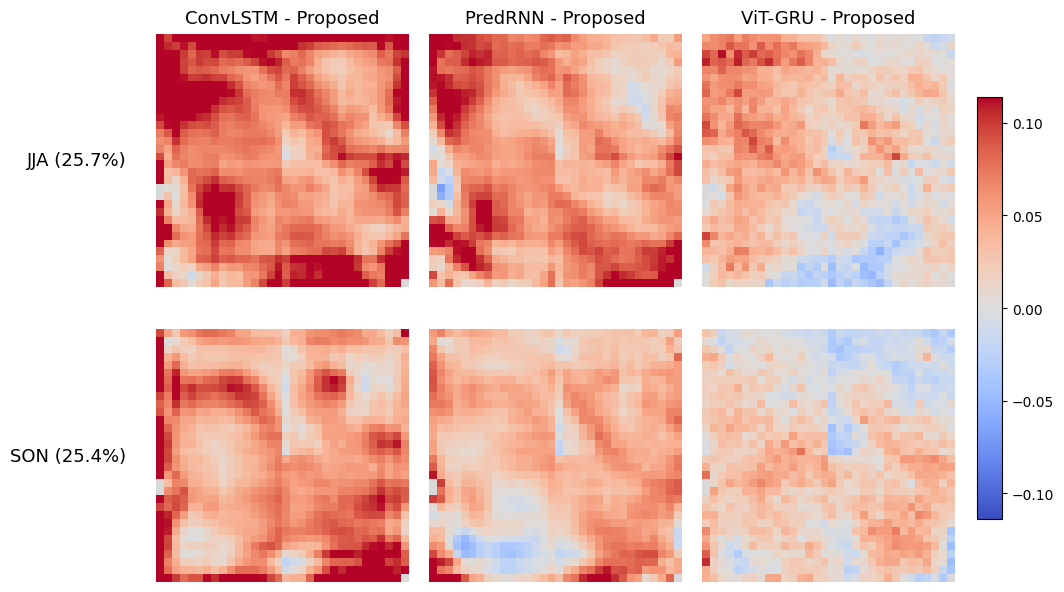


Saved: result_seasonal.png


In [66]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================================================
# Configuration
# =========================================================
MEAN_SST = 22.5081844329834
STD_SST = 4.8933515548706055

GT_PATH = "model_comparison/ground_truth.npy"
MASK_PATH = "data/oisst_spatial_mask_ecs.npy"
PRED_DIR = "model_comparison"

MODEL_NAMES = [
    "ConvLSTM",
    "msfv3_gdl03",   # proposed model
    "predrnn",
    "ViT_GRU",
]

REF_MODEL = "msfv3_gdl03"

START_DATE = "2021-01-15"
TIN = 14
METRIC = "rmse"   # "mae", "rmse", "bias"

SAVE_FIG = True
OUT_FIG = "result_seasonal.png"

MASK_COLOR = "#D9D9D9"
INTERP_MODE = "nearest"
CMAP_DIV = "coolwarm"
DIFF_VMAX_Q = 95

# 논문용: JJA / SON만 사용
SEASONS = ["Summer", "Autumn"]
SEASON_DISPLAY = {
    "Summer": "JJA",
    "Autumn": "SON",
}

MODEL_DISPLAY = {
    "ConvLSTM": "ConvLSTM - Proposed",
    "predrnn": "PredRNN - Proposed",
    "ViT_GRU": "ViT-GRU - Proposed",
}


# =========================================================
# Utilities
# =========================================================
def denorm_sst(x, mean=MEAN_SST, std=STD_SST):
    return x * std + mean


def load_saved_predictions(model_names, pred_dir=PRED_DIR):
    preds_dict = {}
    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if os.path.exists(path):
            preds_dict[name] = np.load(path)
        else:
            print(f"[WARN] Missing file: {path}")
    return preds_dict


def apply_mask_nan(field, mask):
    out = np.asarray(field, dtype=np.float64).copy()
    mask = np.asarray(mask)
    if mask.ndim > 2:
        mask = np.squeeze(mask)
    out[mask <= 0] = np.nan
    return out


def to_nt_hw(arr):
    arr = np.asarray(arr)
    if arr.ndim == 5:
        return arr[:, :, 0, :, :]
    elif arr.ndim == 4:
        return arr
    else:
        raise ValueError(f"Unsupported shape: {arr.shape}")


def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        raise ValueError(f"Invalid month: {month}")


def build_target_date_table(n_samples, tout, start_date=START_DATE, tin=TIN):
    base = pd.to_datetime(start_date)
    date_table = np.empty((n_samples, tout), dtype="datetime64[ns]")

    for i in range(n_samples):
        for t in range(tout):
            date_table[i, t] = base + pd.to_timedelta(i + tin + t, unit="D")

    return pd.to_datetime(date_table.ravel()).values.reshape(n_samples, tout)


def build_season_table(n_samples, tout, start_date=START_DATE, tin=TIN):
    target_dates = build_target_date_table(
        n_samples=n_samples,
        tout=tout,
        start_date=start_date,
        tin=tin,
    )

    season_table = np.empty((n_samples, tout), dtype=object)
    for i in range(n_samples):
        for t in range(tout):
            season_table[i, t] = month_to_season(pd.Timestamp(target_dates[i, t]).month)
    return season_table


def compute_pixel_error_map_from_err_with_mask(err, valid_nt, metric="rmse"):
    valid_nt = np.asarray(valid_nt, dtype=bool)
    valid_4d = valid_nt[:, :, None, None]

    if metric == "mae":
        selected = np.where(valid_4d, np.abs(err), np.nan)
        return np.nanmean(selected, axis=(0, 1))
    elif metric == "rmse":
        selected = np.where(valid_4d, err ** 2, np.nan)
        return np.sqrt(np.nanmean(selected, axis=(0, 1)))
    elif metric == "bias":
        selected = np.where(valid_4d, err, np.nan)
        return np.nanmean(selected, axis=(0, 1))
    else:
        raise ValueError(f"Unsupported metric: {metric}")


# =========================================================
# Error map computation
# =========================================================
def compute_seasonal_error_maps(
    preds_dict,
    gt,
    mask,
    metric="rmse",
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
):
    gt2 = to_nt_hw(gt)
    if denorm:
        gt2 = denorm_sst(gt2, mean=mean, std=std)

    N, T, H, W = gt2.shape
    season_table = build_season_table(
        n_samples=N,
        tout=T,
        start_date=start_date,
        tin=tin,
    )

    error_maps_by_group = {g: {} for g in SEASONS}
    total_count = int(season_table.size)
    group_counts = {season: int(np.sum(season_table == season)) for season in SEASONS}
    group_percents = {season: 100.0 * group_counts[season] / total_count for season in SEASONS}

    for model_name, pred in preds_dict.items():
        pred2 = to_nt_hw(pred)

        if pred2.shape != gt2.shape:
            raise ValueError(
                f"Shape mismatch for {model_name}: pred={pred2.shape}, gt={gt2.shape}"
            )

        if denorm:
            pred2 = denorm_sst(pred2, mean=mean, std=std)

        err = pred2 - gt2

        for season in SEASONS:
            season_mask = (season_table == season)
            season_map = compute_pixel_error_map_from_err_with_mask(
                err, valid_nt=season_mask, metric=metric
            )
            error_maps_by_group[season][model_name] = apply_mask_nan(season_map, mask)

    return error_maps_by_group, group_counts, group_percents


def build_difference_maps_by_group(error_maps_by_group, ref_model):
    diff_maps_by_group = {}

    for group_name, model_map_dict in error_maps_by_group.items():
        if ref_model not in model_map_dict:
            raise ValueError(f"Reference model '{ref_model}' not found in group '{group_name}'")

        ref_map = model_map_dict[ref_model]
        diff_maps_by_group[group_name] = {}

        for model_name, err_map in model_map_dict.items():
            if model_name == ref_model:
                continue
            diff_maps_by_group[group_name][model_name] = err_map - ref_map

    return diff_maps_by_group


# =========================================================
# Visualization
#   - rows: seasons (JJA / SON)
#   - cols: baseline models
#   - row labels: horizontal
#   - no figure title
#   - no colorbar label
# =========================================================
def plot_jja_son_difference_maps(
    diff_maps_by_group,
    group_percents,
    ref_model,
    metric="rmse",
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=False,
    out_fig="jja_son_difference_maps.png",
    mask_color=MASK_COLOR,
):
    row_names = SEASONS

    model_names = []
    for group_name in row_names:
        if group_name in diff_maps_by_group and len(diff_maps_by_group[group_name]) > 0:
            model_names = list(diff_maps_by_group[group_name].keys())
            break

    if len(model_names) == 0:
        raise ValueError("No difference maps found.")

    valid_vals = []
    for group_name in row_names:
        for model_name in model_names:
            m = diff_maps_by_group.get(group_name, {}).get(model_name, None)
            if m is not None:
                vals = m[np.isfinite(m)]
                if vals.size > 0:
                    valid_vals.append(vals)

    if len(valid_vals) == 0:
        raise ValueError("No valid difference maps found.")

    valid_vals = np.concatenate(valid_vals)
    vmax = np.nanpercentile(np.abs(valid_vals), DIFF_VMAX_Q)
    vmax = max(vmax, 1e-8)
    vmin = -vmax

    cmap = mpl.colormaps[cmap_div].copy()
    cmap.set_bad(mask_color)

    nrows = len(row_names)
    ncols = len(model_names)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.8 * ncols, 3.3 * nrows),
        constrained_layout=False,
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    im = None
    for i, group_name in enumerate(row_names):
        for j, model_name in enumerate(model_names):
            ax = axes[i, j]
            m = diff_maps_by_group.get(group_name, {}).get(model_name, None)

            if m is None:
                ax.axis("off")
                continue

            im = ax.imshow(
                m,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation=interpolation,
            )

            if i == 0:
                ax.set_title(
                    MODEL_DISPLAY.get(model_name, f"{model_name} - Proposed"),
                    fontsize=13,
                    pad=8,
                )

            if j == 0:
                ax.text(
                    -0.12,
                    0.5,
                    f"{SEASON_DISPLAY[group_name]} ({group_percents[group_name]:.1f}%)",
                    transform=ax.transAxes,
                    rotation=0,
                    va="center",
                    ha="right",
                    fontsize=13,
                )

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor(mask_color)

            for spine in ax.spines.values():
                spine.set_visible(False)

    fig.subplots_adjust(
        left=0.18,
        right=0.88,
        bottom=0.08,
        top=0.92,
        wspace=0.08,
        hspace=0.14,
    )

    cax = fig.add_axes([0.90, 0.18, 0.022, 0.64])
    fig.colorbar(im, cax=cax)

    if save_fig:
        plt.savefig(out_fig, dpi=300, bbox_inches="tight")

    plt.show()


# =========================================================
# Main
# =========================================================
gt = np.load(GT_PATH)
mask = np.load(MASK_PATH)
preds_dict = load_saved_predictions(MODEL_NAMES)

print("GT shape:", gt.shape)
print("Mask shape:", np.asarray(mask).shape)
for k, v in preds_dict.items():
    print(f"{k}: {v.shape}")

error_maps_by_group, group_counts, group_percents = compute_seasonal_error_maps(
    preds_dict=preds_dict,
    gt=gt,
    mask=mask,
    metric=METRIC,
    denorm=True,
    mean=MEAN_SST,
    std=STD_SST,
    start_date=START_DATE,
    tin=TIN,
)

print("\nGroup counts:")
for group_name in SEASONS:
    print(f"{group_name}: {group_counts[group_name]} ({group_percents[group_name]:.2f}%)")

diff_maps_by_group = build_difference_maps_by_group(
    error_maps_by_group=error_maps_by_group,
    ref_model=REF_MODEL,
)

plot_jja_son_difference_maps(
    diff_maps_by_group=diff_maps_by_group,
    group_percents=group_percents,
    ref_model=REF_MODEL,
    metric=METRIC,
    cmap_div=CMAP_DIV,
    interpolation=INTERP_MODE,
    save_fig=SAVE_FIG,
    out_fig=OUT_FIG,
    mask_color=MASK_COLOR,
)

if SAVE_FIG:
    print(f"\nSaved: {OUT_FIG}")

In [22]:
import numpy as np
import pandas as pd
import os

def denorm_zscore(x, mean, std):
    return x * std + mean

def calculate_global_metrics(preds, gt, mask, eps=1e-6):
    """
    preds, gt: (N, T, C, H, W)
    mask: (H, W) with 1 for valid ocean pixels, 0 for invalid pixels
    """
    m = mask[None, None, None, :, :]  # (1,1,1,H,W)

    diff = preds - gt
    diff2 = diff ** 2
    abs_diff = np.abs(diff)

    total_valid = np.sum(m) * preds.shape[0] * preds.shape[1] * preds.shape[2]

    # RMSE
    global_mse = np.nansum(diff2 * m) / total_valid
    global_rmse = np.sqrt(global_mse)

    # MAE
    global_mae = np.nansum(abs_diff * m) / total_valid

    # MAPE
    denom = np.clip(np.abs(gt), eps, None)
    ape = (abs_diff / denom) * m
    global_mape = np.nansum(ape) / total_valid * 100.0

    return {
        "Global_RMSE": global_rmse,
        "Global_MAE": global_mae,
        "Global_MAPE": global_mape,
    }


# --- 실행부 ---
gt = np.load("model_comparison/ground_truth.npy")
mask = np.load("data/oisst_spatial_mask_ecs.npy").astype(np.float32)

model_names = [
    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU",
    "swinLstm_B"
]


USE_DENORM = True

# =========================
# 경우 2: z-score 정규화 상태면 mean/std 넣기
# =========================
mean = 22.5081844329834
std  = 4.8933515548706055

results = []

for name in model_names:
    path = f"model_comparison/{name}_preds.npy"
    if not os.path.exists(path):
        continue

    preds = np.load(path)

    if USE_DENORM:
        preds_eval = denorm_zscore(preds, mean, std)
        gt_eval = denorm_zscore(gt, mean, std)
    else:
        preds_eval = preds
        gt_eval = gt

    metrics = calculate_global_metrics(preds_eval, gt_eval, mask, eps=1e-6)
    results.append({
        "Model": name,
        **metrics
    })

df = pd.DataFrame(results).sort_values("Global_RMSE").reset_index(drop=True)
print("=== Final Global Performance Ranking ===")
print(df)

=== Final Global Performance Ranking ===
          Model  Global_RMSE  Global_MAE  Global_MAPE
0  msfv3_base03     0.536931    0.380283     1.748776
1       ViT_GRU     0.550601    0.392176     1.820175
2       predrnn     0.562803    0.398739     1.819979
3    swinLstm_B     0.564263    0.404829     1.866705
4           MIM     0.564842    0.403984     1.841365
5      ConvLSTM     0.580295    0.411936     1.883885
6    simvp_gsta     0.596430    0.432398     1.961532
7  SimVP_INCEPU     0.640498    0.473784     2.186922


In [24]:
import pandas as pd
import numpy as np

start_date = "2021-01-15"
num_samples = 1792

# 2. 날짜 시퀀스 생성 (하루 단위)
date_indices = pd.date_range(start=start_date, periods=num_samples, freq='D')

# 3. 각 날짜에서 '월' 정보 추출
all_meta_months = date_indices.month.values

print(f"Generated metadata for {num_samples} samples.")
print(f"First sample month: {all_meta_months[0]} ({date_indices[0].date()})")
print(f"Last sample month: {all_meta_months[-1]} ({date_indices[-1].date()})")

Generated metadata for 1792 samples.
First sample month: 1 (2021-01-15)
Last sample month: 12 (2025-12-11)


In [25]:
model_names = [

    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU",
    "swinLstm_B"
    
]

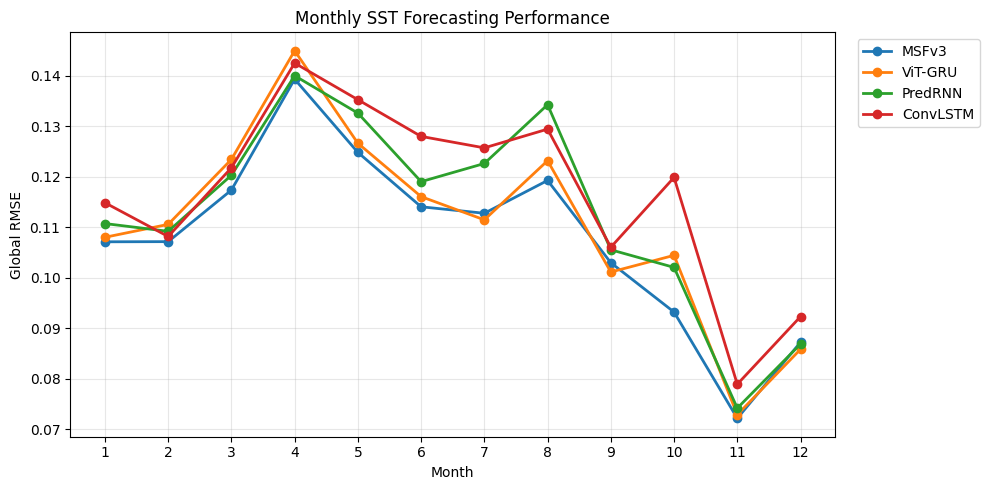

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def analyze_monthly_performance(model_names, gt, mask, all_meta_months):
    """
    각 모델의 월별 Global RMSE를 계산하고 DataFrame으로 반환
    """
    monthly_results = []
    months = np.array(all_meta_months)

    for name in model_names:
        preds = np.load(f"model_comparison/{name}_preds.npy")

        for m_idx in range(1, 13):
            idx = np.where(months == m_idx)[0]
            if len(idx) == 0:
                continue

            p_m = preds[idx]
            y_m = gt[idx]

            diff2 = (p_m - y_m) ** 2
            m = mask[None, None, None, :, :]

            mse_m = np.nansum(diff2 * m) / (
                np.sum(m) * p_m.shape[0] * p_m.shape[1] * p_m.shape[2]
            )
            rmse_m = np.sqrt(mse_m)

            monthly_results.append({
                "Model": name,
                "Month": m_idx,
                "RMSE": rmse_m
            })

    return pd.DataFrame(monthly_results)


# -----------------------------
# 실행
# -----------------------------
df_monthly = analyze_monthly_performance(model_names, gt, mask, all_meta_months)

# 보기 좋게 이름 바꾸고 싶으면 여기서 매핑
name_map = {
    "msfv3_base03": "MSFv3",
    "predrnn": "PredRNN",
    "swinLstm_B": "SwinLSTM-B",
    "simvp_gsta": "SimVP-gSTA",
    "SimVP_INCEPU": "SimVP-IncepU",
    "ViT_GRU": "ViT-GRU",
    "ConvLSTM": "ConvLSTM",
    "MIM": "MIM",
}

df_monthly["Model"] = df_monthly["Model"].replace(name_map)

# 모델 순서 지정하고 싶으면
model_order = [
    "MSFv3",
    "ViT-GRU",
    "PredRNN",
    "ConvLSTM",
]

# 실제 있는 모델만 필터
model_order = [m for m in model_order if m in df_monthly["Model"].unique()]

# -----------------------------
# 그래프 1: 월별 RMSE line plot
# -----------------------------
plt.figure(figsize=(10, 5))

for model in model_order:
    sub = df_monthly[df_monthly["Model"] == model].sort_values("Month")
    plt.plot(sub["Month"], sub["RMSE"], marker="o", linewidth=2, label=model)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Global RMSE")
plt.title("Monthly SST Forecasting Performance")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

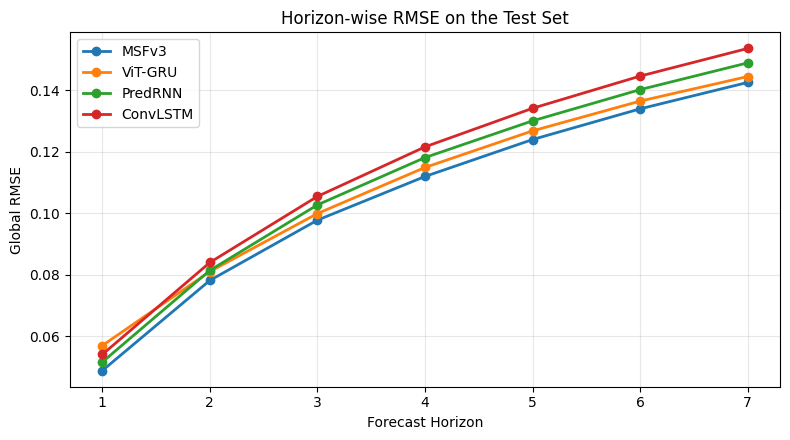

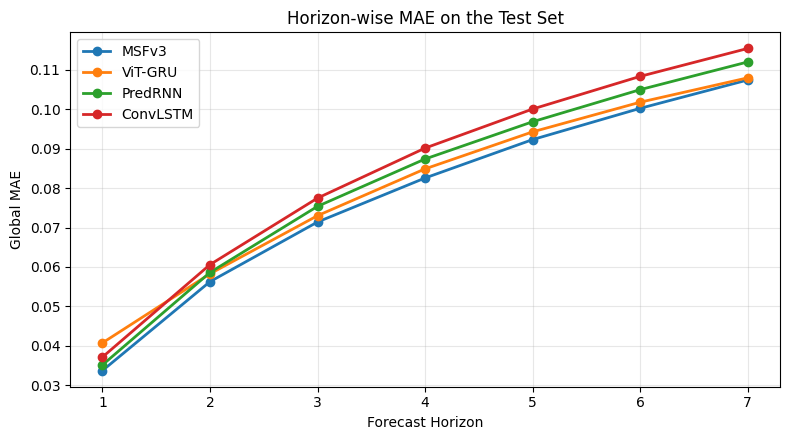

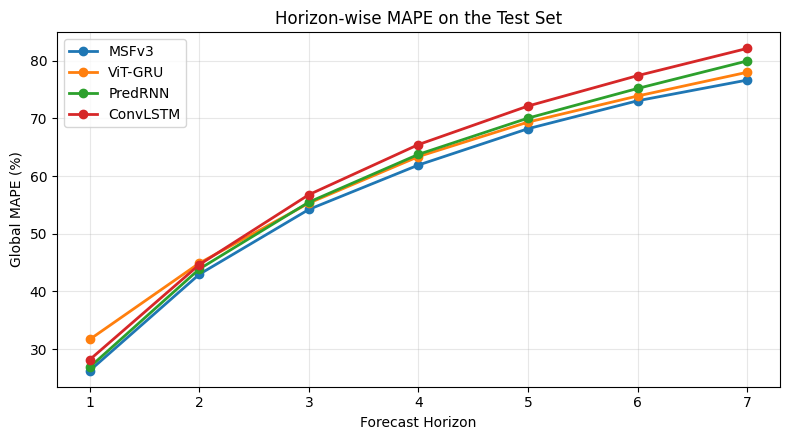

=== Horizon-wise RMSE ===


Model,ConvLSTM,MIM,MSFv3,PredRNN,SimVP-IncepU,SimVP-gSTA,SwinLSTM-B,ViT-GRU
Horizon,,,,,,,,
1,0.05412,0.05221,0.04888,0.05166,0.09745,0.08558,0.06299,0.05703
2,0.08404,0.08208,0.07821,0.08146,0.11024,0.09849,0.08479,0.08109
3,0.10552,0.10284,0.09781,0.10277,0.12248,0.11266,0.10337,0.09995
4,0.12163,0.11855,0.11200,0.11815,0.13219,0.12276,0.11738,0.11493
5,0.13417,0.13071,0.12401,0.13009,0.14059,0.13362,0.12894,0.12683
6,0.14464,0.14077,0.13399,0.14024,0.14895,0.14023,0.13870,0.13651
7,0.15363,0.14925,0.14258,0.14893,0.15444,0.14727,0.14696,0.14449


=== Horizon-wise MAE ===


Model,ConvLSTM,MIM,MSFv3,PredRNN,SimVP-IncepU,SimVP-gSTA,SwinLSTM-B,ViT-GRU
Horizon,,,,,,,,
1,0.03711,0.03621,0.03368,0.03511,0.07200,0.05877,0.04543,0.04072
2,0.06059,0.05955,0.05626,0.05859,0.08184,0.07092,0.06118,0.05826
3,0.07748,0.07600,0.07141,0.07538,0.09146,0.08247,0.07566,0.07302
4,0.09017,0.08852,0.08258,0.08740,0.09921,0.09092,0.08670,0.08490
5,0.10009,0.09824,0.09233,0.09686,0.10537,0.09976,0.09593,0.09429
6,0.10838,0.10629,0.10026,0.10501,0.11168,0.10494,0.10377,0.10182
7,0.11547,0.11309,0.10747,0.11204,0.11619,0.11076,0.11044,0.10800


=== Horizon-wise MAPE ===


Model,ConvLSTM,MIM,MSFv3,PredRNN,SimVP-IncepU,SimVP-gSTA,SwinLSTM-B,ViT-GRU
Horizon,,,,,,,,
1,28.174629,27.762381,26.270720,26.881701,52.005791,37.664661,34.892620,31.684271
2,44.642700,45.491798,42.968948,43.883499,59.586182,48.610020,46.231281,44.904839
3,56.772430,57.370659,54.215099,55.480518,64.984100,57.276131,57.106400,55.308289
4,65.460922,66.043221,61.911442,63.762501,71.248741,64.695129,64.960930,63.377789
5,72.139610,72.777092,68.207809,70.045197,74.263741,71.033218,71.641418,69.354736
6,77.407249,78.426628,73.052063,75.182442,77.966560,73.953117,77.062241,73.878822
7,82.122520,83.288643,76.638580,79.950981,81.172897,77.855530,82.123238,77.988403


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def calculate_horizon_metrics(preds, gt, mask, eps=1e-6):
    """
    preds, gt: (N, T, C, H, W)
    mask: (H, W)

    return:
        rmse_t: (T,)
        mae_t:  (T,)
        mape_t: (T,)
    """
    assert preds.shape == gt.shape, f"Shape mismatch: preds={preds.shape}, gt={gt.shape}"

    N, T, C, H, W = preds.shape
    m = mask[None, None, None, :, :]   # (1,1,1,H,W)

    rmse_t = []
    mae_t = []
    mape_t = []

    for t in range(T):
        p_t = preds[:, t:t+1]   # (N,1,C,H,W)
        y_t = gt[:, t:t+1]

        diff = p_t - y_t
        diff2 = diff ** 2
        abs_diff = np.abs(diff)

        total_valid = np.sum(m) * p_t.shape[0] * p_t.shape[1] * p_t.shape[2]

        # RMSE
        mse = np.nansum(diff2 * m) / total_valid
        rmse = np.sqrt(mse)

        # MAE
        mae = np.nansum(abs_diff * m) / total_valid

        # MAPE
        denom = np.clip(np.abs(y_t), eps, None)
        ape = (abs_diff / denom) * m
        mape = np.nansum(ape) / total_valid * 100.0

        rmse_t.append(rmse)
        mae_t.append(mae)
        mape_t.append(mape)

    return np.array(rmse_t), np.array(mae_t), np.array(mape_t)


def analyze_horizon_performance(model_names, gt, mask, pred_dir="model_comparison", eps=1e-6):
    """
    모든 모델의 horizon-wise metric 계산
    """
    rows = []

    for name in model_names:
        path = os.path.join(pred_dir, f"{name}_preds.npy")
        if not os.path.exists(path):
            print(f"[SKIP] not found: {path}")
            continue

        preds = np.load(path)

        rmse_t, mae_t, mape_t = calculate_horizon_metrics(preds, gt, mask, eps=eps)

        for t in range(len(rmse_t)):
            rows.append({
                "Model": name,
                "Horizon": t + 1,
                "RMSE": rmse_t[t],
                "MAE": mae_t[t],
                "MAPE": mape_t[t],
            })

    return pd.DataFrame(rows)


# -----------------------------
# 실행
# -----------------------------
gt = np.load("model_comparison/ground_truth.npy")   # (N,T,C,H,W)
mask = np.load("data/oisst_spatial_mask_ecs.npy").astype(np.float32)

model_names = [
    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU",
    "swinLstm_B",
]

df_horizon = analyze_horizon_performance(model_names, gt, mask)

# 보기 좋게 이름 변경
name_map = {
    "msfv3_base03": "MSFv3",
    "predrnn": "PredRNN",
    "swinLstm_B": "SwinLSTM-B",
    "simvp_gsta": "SimVP-gSTA",
    "SimVP_INCEPU": "SimVP-IncepU",
    "ViT_GRU": "ViT-GRU",
    "ConvLSTM": "ConvLSTM",
    "MIM": "MIM",
}
df_horizon["Model"] = df_horizon["Model"].replace(name_map)

# 그래프에 넣을 모델만 선택
model_order = [
    "MSFv3",
    "ViT-GRU",
    "PredRNN",
    "ConvLSTM",
]
model_order = [m for m in model_order if m in df_horizon["Model"].unique()]

# -----------------------------
# Horizon-wise RMSE plot
# -----------------------------
plt.figure(figsize=(8, 4.5))
for model in model_order:
    sub = df_horizon[df_horizon["Model"] == model].sort_values("Horizon")
    plt.plot(sub["Horizon"], sub["RMSE"], marker="o", linewidth=2, label=model)

plt.xlabel("Forecast Horizon")
plt.ylabel("Global RMSE")
plt.title("Horizon-wise RMSE on the Test Set")
plt.xticks(sorted(df_horizon["Horizon"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Horizon-wise MAE plot
# -----------------------------
plt.figure(figsize=(8, 4.5))
for model in model_order:
    sub = df_horizon[df_horizon["Model"] == model].sort_values("Horizon")
    plt.plot(sub["Horizon"], sub["MAE"], marker="o", linewidth=2, label=model)

plt.xlabel("Forecast Horizon")
plt.ylabel("Global MAE")
plt.title("Horizon-wise MAE on the Test Set")
plt.xticks(sorted(df_horizon["Horizon"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Horizon-wise MAPE plot
# -----------------------------
plt.figure(figsize=(8, 4.5))
for model in model_order:
    sub = df_horizon[df_horizon["Model"] == model].sort_values("Horizon")
    plt.plot(sub["Horizon"], sub["MAPE"], marker="o", linewidth=2, label=model)

plt.xlabel("Forecast Horizon")
plt.ylabel("Global MAPE (%)")
plt.title("Horizon-wise MAPE on the Test Set")
plt.xticks(sorted(df_horizon["Horizon"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# 표 형태로도 확인
# -----------------------------
df_rmse = df_horizon.pivot(index="Horizon", columns="Model", values="RMSE").round(5)
df_mae  = df_horizon.pivot(index="Horizon", columns="Model", values="MAE").round(5)
df_mape = df_horizon.pivot(index="Horizon", columns="Model", values="MAPE").round(5)

print("=== Horizon-wise RMSE ===")
display(df_rmse)

print("=== Horizon-wise MAE ===")
display(df_mae)

print("=== Horizon-wise MAPE ===")
display(df_mape)

Start date: 2021-01-15
End date: 2025-12-11


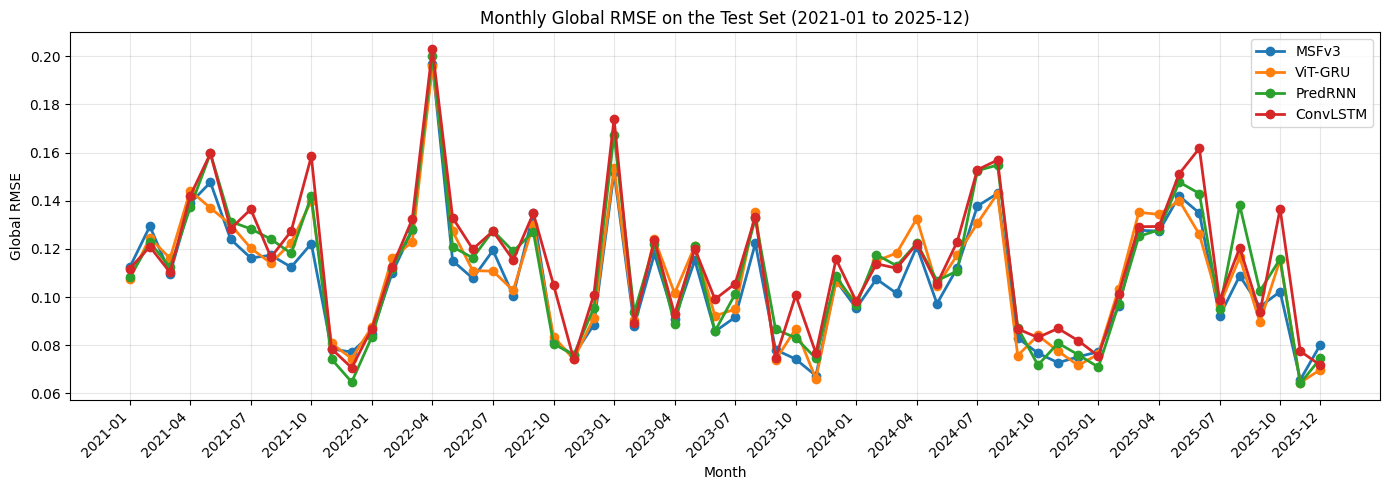

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def calculate_global_rmse(preds, gt, mask):
    """
    preds, gt: (N, T, C, H, W)
    mask: (H, W)
    """
    diff2 = (preds - gt) ** 2
    m = mask[None, None, None, :, :]  # (1, 1, 1, H, W)

    sum_sq_error = np.nansum(diff2 * m)
    total_valid = np.sum(m) * preds.shape[0] * preds.shape[1] * preds.shape[2]

    mse = sum_sq_error / total_valid
    rmse = np.sqrt(mse)
    return rmse


def analyze_yearmonth_rmse(model_names, gt, mask, date_indices, pred_dir="model_comparison"):
    """
    date_indices: 각 sample에 대응하는 날짜 시퀀스 (길이 N)
                  예: pd.date_range(...)
    """
    year_month = pd.PeriodIndex(date_indices, freq="M")
    rows = []

    for name in model_names:
        pred_path = os.path.join(pred_dir, f"{name}_preds.npy")
        if not os.path.exists(pred_path):
            print(f"[SKIP] not found: {pred_path}")
            continue

        preds = np.load(pred_path)

        if len(preds) != len(year_month):
            raise ValueError(
                f"{name}: preds sample count ({len(preds)}) != date count ({len(year_month)})"
            )

        for ym in sorted(year_month.unique()):
            idx = np.where(year_month == ym)[0]
            if len(idx) == 0:
                continue

            preds_m = preds[idx]
            gt_m = gt[idx]
            rmse_m = calculate_global_rmse(preds_m, gt_m, mask)

            rows.append({
                "Model": name,
                "YearMonth": str(ym),   # 
                "RMSE": rmse_m,
                "NumSamples": len(idx),
            })

    return pd.DataFrame(rows)


# =========================
# 데이터 로드
# =========================
gt = np.load("model_comparison/ground_truth.npy")
mask = np.load("./data/oisst_spatial_mask_ecs.npy").astype(np.float32)

# mask가 (H, W)가 아니라 (1, H, W) 같은 형태면 아래처럼 맞춰도 됨
if mask.ndim > 2:
    mask = np.squeeze(mask)

# =========================
# 날짜 복원
# =========================
start_date = "2021-01-15"
num_samples = 1792

date_indices = pd.date_range(start=start_date, periods=num_samples, freq="D")

print(f"Start date: {date_indices[0].date()}")
print(f"End date: {date_indices[-1].date()}")

# =========================
# 모델 목록
# =========================
model_names = [
    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU",
    "swinLstm_B",
]

# =========================
# 월별(YYYY-MM) RMSE 계산
# =========================
df_time = analyze_yearmonth_rmse(
    model_names=model_names,
    gt=gt,
    mask=mask,
    date_indices=date_indices,
    pred_dir="model_comparison",
)

# 보기 좋게 이름 변경
name_map = {
    "msfv3_base03": "MSFv3",
    "predrnn": "PredRNN",
    "swinLstm_B": "SwinLSTM-B",
    "simvp_gsta": "SimVP-gSTA",
    "SimVP_INCEPU": "SimVP-IncepU",
    "ViT_GRU": "ViT-GRU",
    "ConvLSTM": "ConvLSTM",
    "MIM": "MIM",
}
df_time["Model"] = df_time["Model"].replace(name_map)

# 그래프에 넣을 모델만 선택
model_order = [
    "MSFv3",
    "ViT-GRU",
    "PredRNN",
    "ConvLSTM",
]
model_order = [m for m in model_order if m in df_time["Model"].unique()]

# x축 정렬용
all_x = sorted(df_time["YearMonth"].unique())
x_to_int = {x: i for i, x in enumerate(all_x)}

# =========================
# 시계열 그래프
# =========================
plt.figure(figsize=(14, 5))

for model in model_order:
    sub = df_time[df_time["Model"] == model].copy()
    sub["x"] = sub["YearMonth"].map(x_to_int)
    sub = sub.sort_values("x")

    plt.plot(sub["x"], sub["RMSE"], marker="o", linewidth=2, label=model)

step = 3  # 3개월 간격 tick
tick_positions = list(range(0, len(all_x), step))
if tick_positions[-1] != len(all_x) - 1:
    tick_positions.append(len(all_x) - 1)

tick_labels = [all_x[i] for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("Global RMSE")
plt.title("Monthly Global RMSE on the Test Set (2021-01 to 2025-12)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


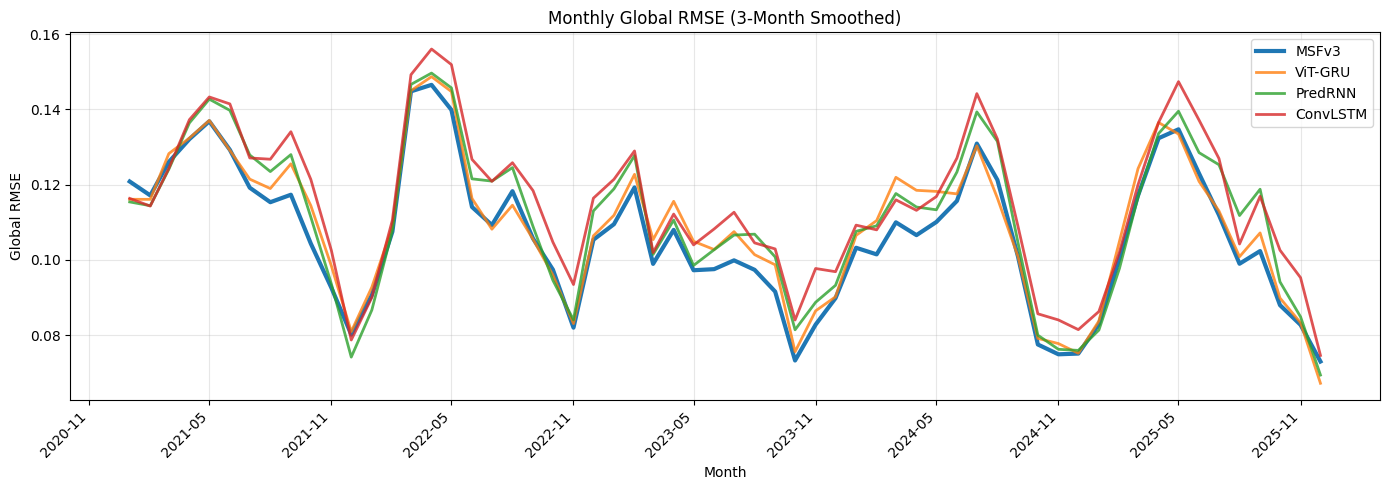

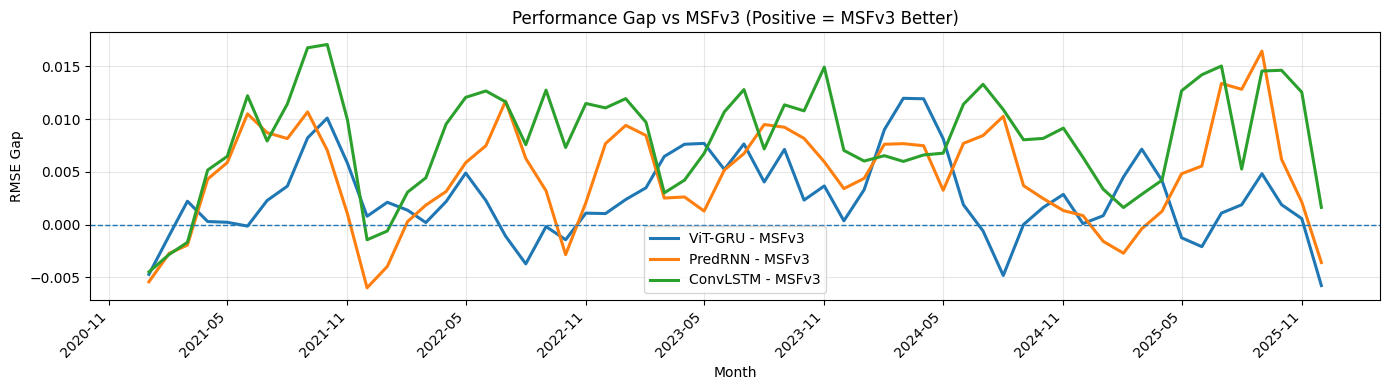

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# plot용 데이터 준비
# =========================
plot_df = df_time[df_time["Model"].isin(model_order)].copy()
plot_df["Date"] = pd.PeriodIndex(plot_df["YearMonth"], freq="M").to_timestamp()
plot_df = plot_df.sort_values(["Model", "Date"])



# 3개월 rolling mean
plot_df["RMSE_smooth"] = (
    plot_df.groupby("Model")["RMSE"]
    .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).mean())
)

# =========================
# 1. smoothed monthly line plot
# =========================
plt.figure(figsize=(14, 5))

for model in model_order:
    sub = plot_df[plot_df["Model"] == model].copy()

    lw = 3.0 if model == "MSFv3" else 2.0
    alpha = 1.0 if model == "MSFv3" else 0.8

    plt.plot(
        sub["Date"],
        sub["RMSE_smooth"],
        linewidth=lw,
        alpha=alpha,
        label=model
    )

# x축 간격 줄이기
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.xlabel("Month")
plt.ylabel("Global RMSE")
plt.title("Monthly Global RMSE (3-Month Smoothed)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# 2. MSFv3 대비 성능 차이(gap) plot
#    양수면 baseline이 더 나쁘고, 즉 MSFv3가 더 좋다는 뜻
# =========================
pivot_raw = plot_df.pivot(index="Date", columns="Model", values="RMSE")
pivot_smooth = plot_df.pivot(index="Date", columns="Model", values="RMSE_smooth")

ref_model = "MSFv3"
baseline_models = [m for m in model_order if m != ref_model and m in pivot_smooth.columns]

gap_df = pivot_smooth[baseline_models].sub(pivot_smooth[ref_model], axis=0)

plt.figure(figsize=(14, 4))

for model in baseline_models:
    plt.plot(
        gap_df.index,
        gap_df[model],
        linewidth=2.2,
        label=f"{model} - {ref_model}"
    )

plt.axhline(0, linestyle="--", linewidth=1)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.xlabel("Month")
plt.ylabel("RMSE Gap")
plt.title("Performance Gap vs MSFv3 (Positive = MSFv3 Better)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Start date: 2021-01-15
End date: 2025-12-11


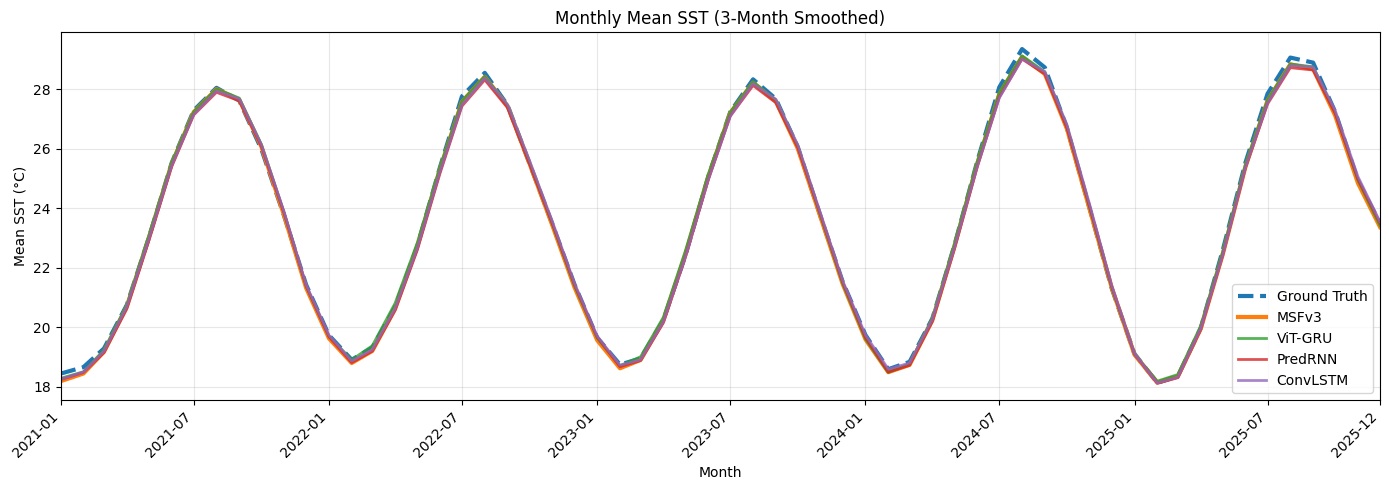

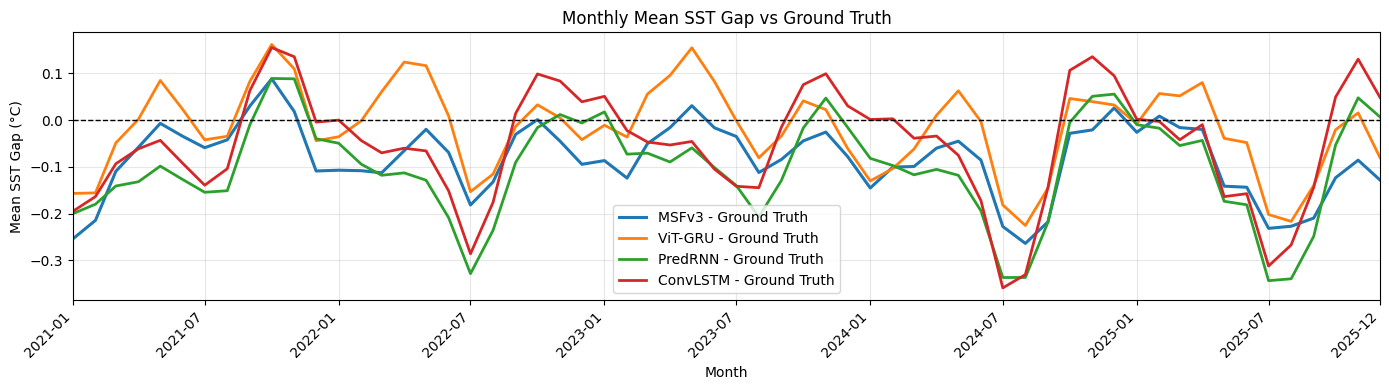

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# 설정
# =========================================================
pred_dir = "model_comparison"
gt_path = os.path.join(pred_dir, "ground_truth.npy")
mask_path = "./data/oisst_spatial_mask_ecs.npy"

mean = 22.5081844329834
std = 4.8933515548706055

start_date = "2021-01-15"
num_samples = 1792

model_names = [
    "ConvLSTM",
    "MIM",
    "msfv3_base03",
    "predrnn",
    "simvp_gsta",
    "SimVP_INCEPU",
    "ViT_GRU",
    "swinLstm_B",
]

name_map = {
    "msfv3_base03": "MSFv3",
    "predrnn": "PredRNN",
    "swinLstm_B": "SwinLSTM-B",
    "simvp_gsta": "SimVP-gSTA",
    "SimVP_INCEPU": "SimVP-IncepU",
    "ViT_GRU": "ViT-GRU",
    "ConvLSTM": "ConvLSTM",
    "MIM": "MIM",
    "GroundTruth": "Ground Truth",
}

model_order = [
    "Ground Truth",
    "MSFv3",
    "ViT-GRU",
    "PredRNN",
    "ConvLSTM",
]

# =========================================================
# 유틸
# =========================================================
def calculate_global_mean_temp(x, mask, mean, std):
    """
    x: (N, T, C, H, W), normalized
    mask: (H, W)
    """
    x_denorm = x * std + mean
    m = mask[None, None, None, :, :]
    weighted_sum = np.nansum(x_denorm * m)
    total_valid = np.sum(m) * x.shape[0] * x.shape[1] * x.shape[2]
    return weighted_sum / total_valid


def build_xticks_with_endpoints(date_start, date_end, interval_months=6):
    tick_dates = pd.date_range(start=date_start, end=date_end, freq=f"{interval_months}MS").tolist()

    if len(tick_dates) == 0 or tick_dates[0] != date_start:
        tick_dates = [date_start] + tick_dates

    if tick_dates[-1] != date_end:
        tick_dates.append(date_end)

    # 중복 제거 + 정렬
    tick_dates = sorted(pd.to_datetime(pd.Series(tick_dates).unique()))
    return tick_dates


def analyze_yearmonth_mean_temp_with_gt(
    model_names,
    gt,
    mask,
    date_indices,
    pred_dir,
    mean,
    std,
):
    year_month = pd.PeriodIndex(date_indices, freq="M")
    rows = []

    # ---------- Ground Truth ----------
    for ym in sorted(year_month.unique()):
        idx = np.where(year_month == ym)[0]
        if len(idx) == 0:
            continue

        gt_m = gt[idx]
        mean_temp_m = calculate_global_mean_temp(gt_m, mask, mean, std)

        rows.append({
            "Model": "GroundTruth",
            "YearMonth": str(ym),
            "MeanTemp": mean_temp_m,
            "NumSamples": len(idx),
        })

    # ---------- Predictions ----------
    for name in model_names:
        pred_path = os.path.join(pred_dir, f"{name}_preds.npy")
        if not os.path.exists(pred_path):
            print(f"[SKIP] not found: {pred_path}")
            continue

        preds = np.load(pred_path)

        if len(preds) != len(year_month):
            raise ValueError(
                f"{name}: preds sample count ({len(preds)}) != date count ({len(year_month)})"
            )

        for ym in sorted(year_month.unique()):
            idx = np.where(year_month == ym)[0]
            if len(idx) == 0:
                continue

            preds_m = preds[idx]
            mean_temp_m = calculate_global_mean_temp(preds_m, mask, mean, std)

            rows.append({
                "Model": name,
                "YearMonth": str(ym),
                "MeanTemp": mean_temp_m,
                "NumSamples": len(idx),
            })

    return pd.DataFrame(rows)


# =========================================================
# 데이터 로드
# =========================================================
gt = np.load(gt_path)
mask = np.load(mask_path).astype(np.float32)
if mask.ndim > 2:
    mask = np.squeeze(mask)

date_indices = pd.date_range(start=start_date, periods=num_samples, freq="D")

print(f"Start date: {date_indices[0].date()}")
print(f"End date: {date_indices[-1].date()}")

# =========================================================
# 월별 평균 온도 계산
# =========================================================
df_temp = analyze_yearmonth_mean_temp_with_gt(
    model_names=model_names,
    gt=gt,
    mask=mask,
    date_indices=date_indices,
    pred_dir=pred_dir,
    mean=mean,
    std=std,
)

df_temp["Model"] = df_temp["Model"].replace(name_map)
df_temp["Date"] = pd.PeriodIndex(df_temp["YearMonth"], freq="M").to_timestamp()
df_temp = df_temp.sort_values(["Model", "Date"]).reset_index(drop=True)

# 3개월 rolling mean
df_temp["MeanTemp_smooth"] = (
    df_temp.groupby("Model")["MeanTemp"]
    .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).mean())
)

# 필요한 모델만 남기기
plot_df = df_temp[df_temp["Model"].isin(model_order)].copy()

date_start = plot_df["Date"].min()
date_end = plot_df["Date"].max()
tick_dates = build_xticks_with_endpoints(date_start, date_end, interval_months=6)

# =========================================================
# 그래프 1: 월별 평균 예측 온도 + Ground Truth
# =========================================================
plt.figure(figsize=(14, 5))

for model in model_order:
    sub = plot_df[plot_df["Model"] == model].copy()
    if len(sub) == 0:
        continue

    if model == "Ground Truth":
        lw = 3.0
        ls = "--"
        alpha = 1.0
    elif model == "MSFv3":
        lw = 3.0
        ls = "-"
        alpha = 1.0
    else:
        lw = 2.0
        ls = "-"
        alpha = 0.8

    plt.plot(
        sub["Date"],
        sub["MeanTemp_smooth"],
        linewidth=lw,
        linestyle=ls,
        alpha=alpha,
        label=model,
    )

ax = plt.gca()
ax.set_xlim(date_start, date_end)
ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.xlabel("Month")
plt.ylabel("Mean SST (°C)")
plt.title("Monthly Mean SST (3-Month Smoothed)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 그래프 2: Ground Truth 대비 온도 차이
#   양수면 해당 모델이 GT보다 더 따뜻하게 예측
#   음수면 해당 모델이 GT보다 더 차갑게 예측
# =========================================================
pivot_temp = plot_df.pivot(index="Date", columns="Model", values="MeanTemp_smooth")
ref_model = "Ground Truth"
baseline_models = [m for m in model_order if m != ref_model and m in pivot_temp.columns]

temp_gap_df = pivot_temp[baseline_models].sub(pivot_temp[ref_model], axis=0)

plt.figure(figsize=(14, 4))

for model in baseline_models:
    plt.plot(
        temp_gap_df.index,
        temp_gap_df[model],
        linewidth=2.2 if model == "MSFv3" else 2.0,
        label=f"{model} - {ref_model}",
    )

plt.axhline(0, linestyle="--", linewidth=1, color="black")
ax = plt.gca()
ax.set_xlim(date_start, date_end)
ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.xlabel("Month")
plt.ylabel("Mean SST Gap (°C)")
plt.title("Monthly Mean SST Gap vs Ground Truth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

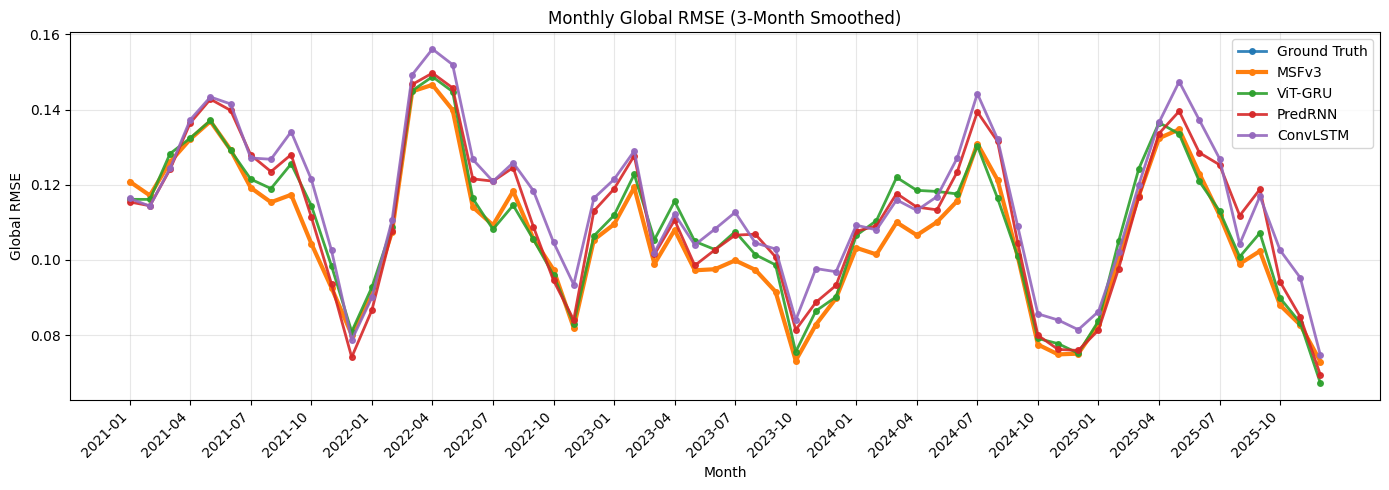

In [31]:
import matplotlib.pyplot as plt

# =========================
# plot용 데이터 준비
# =========================
plot_df = df_time[df_time["Model"].isin(model_order)].copy()
plot_df["Date"] = pd.PeriodIndex(plot_df["YearMonth"], freq="M").to_timestamp()
plot_df = plot_df.sort_values(["Model", "Date"])

# 3개월 rolling mean
plot_df["RMSE_smooth"] = (
    plot_df.groupby("Model")["RMSE"]
    .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).mean())
)

# x축 정렬용 (두 번째 사진 스타일)
all_x = sorted(plot_df["YearMonth"].unique())
x_to_int = {x: i for i, x in enumerate(all_x)}

# =========================
# smoothed monthly line plot
# =========================
plt.figure(figsize=(14, 5))

for model in model_order:
    sub = plot_df[plot_df["Model"] == model].copy()
    sub["x"] = sub["YearMonth"].map(x_to_int)
    sub = sub.sort_values("x")

    lw = 3.0 if model == "MSFv3" else 2.0
    alpha = 1.0 if model == "MSFv3" else 0.9

    plt.plot(
        sub["x"],
        sub["RMSE_smooth"],
        marker="o",          # 점 추가
        markersize=4,        # 점 크기
        linewidth=lw,
        alpha=alpha,
        label=model
    )

# 두 번째 사진처럼 월 레이블 표시
step = 3   # 3개월 간격. 매달 다 보려면 step = 1
plt.xticks(
    range(0, len(all_x), step),
    all_x[::step],
    rotation=45,
    ha="right"
)

plt.xlabel("Month")
plt.ylabel("Global RMSE")
plt.title("Monthly Global RMSE (3-Month Smoothed)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_256482/2439366648.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


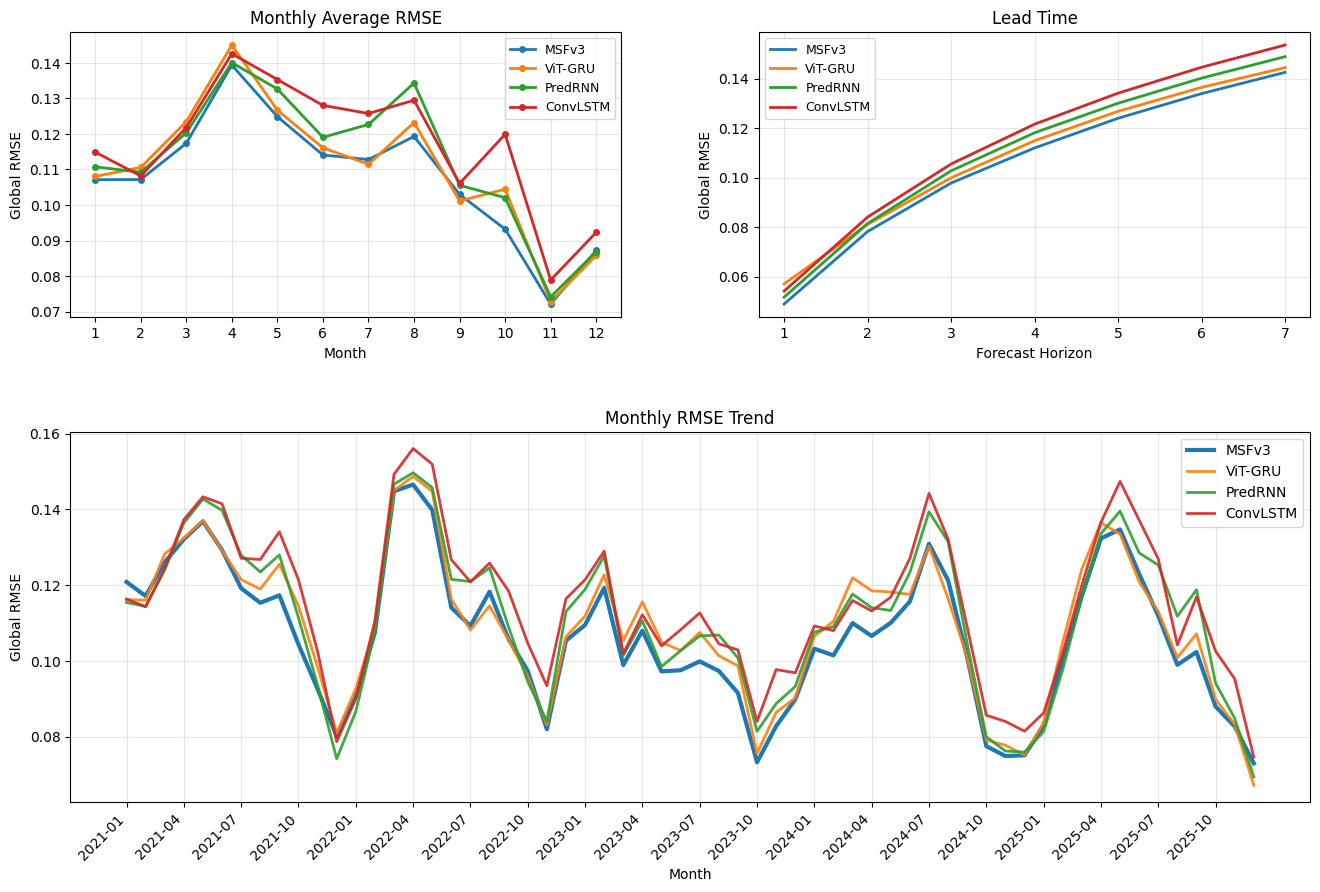

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# 공통 설정
# --------------------------------------------------
model_order = ["MSFv3", "ViT-GRU", "PredRNN", "ConvLSTM"]

# 실제 존재하는 모델만 남기기
model_order_monthly = [m for m in model_order if m in df_monthly["Model"].unique()]
model_order_horizon = [m for m in model_order if m in df_horizon["Model"].unique()]
model_order_time = [m for m in model_order if m in df_time["Model"].unique()]

# --------------------------------------------------
# 아래쪽(smoothed monthly)용 데이터 준비
# --------------------------------------------------
plot_df = df_time[df_time["Model"].isin(model_order_time)].copy()
plot_df["Date"] = pd.PeriodIndex(plot_df["YearMonth"], freq="M").to_timestamp()
plot_df = plot_df.sort_values(["Model", "Date"])

plot_df["RMSE_smooth"] = (
    plot_df.groupby("Model")["RMSE"]
    .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).mean())
)

all_x = sorted(plot_df["YearMonth"].unique())
x_to_int = {x: i for i, x in enumerate(all_x)}

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.3],
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])   # 왼쪽 위
ax2 = fig.add_subplot(gs[0, 1])   # 오른쪽 위
ax3 = fig.add_subplot(gs[1, :])   # 아래 전체

# --------------------------------------------------
# 1) 왼쪽 위: 월별 RMSE (Month = 1~12)
# --------------------------------------------------
for model in model_order_monthly:
    sub = df_monthly[df_monthly["Model"] == model].sort_values("Month")
    ax1.plot(
        sub["Month"],
        sub["RMSE"],
        marker="o",
        markersize=4,
        linewidth=2,
        label=model
    )

ax1.set_xticks(range(1, 13))
ax1.set_xlabel("Month")
ax1.set_ylabel("Global RMSE")
ax1.set_title("Monthly Average RMSE")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# --------------------------------------------------
# 2) 오른쪽 위: Horizon-wise RMSE
# --------------------------------------------------
for model in model_order_horizon:
    sub = df_horizon[df_horizon["Model"] == model].sort_values("Horizon")
    ax2.plot(
        sub["Horizon"],
        sub["RMSE"],

        linewidth=2,
        label=model
    )

ax2.set_xticks(sorted(df_horizon["Horizon"].unique()))
ax2.set_xlabel("Forecast Horizon")
ax2.set_ylabel("Global RMSE")
ax2.set_title("Lead Time")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# --------------------------------------------------
# 3) 아래 전체: Year-Month smoothed RMSE
# --------------------------------------------------
for model in model_order_time:
    sub = plot_df[plot_df["Model"] == model].copy()
    sub["x"] = sub["YearMonth"].map(x_to_int)
    sub = sub.sort_values("x")

    lw = 3.0 if model == "MSFv3" else 2.0
    alpha = 1.0 if model == "MSFv3" else 0.9

    ax3.plot(
        sub["x"],
        sub["RMSE_smooth"],

        linewidth=lw,
        alpha=alpha,
        label=model
    )

step = 3  # 3개월 간격
ax3.set_xticks(range(0, len(all_x), step))
ax3.set_xticklabels(all_x[::step], rotation=45, ha="right")
ax3.set_xlabel("Month")
ax3.set_ylabel("Global RMSE")
ax3.set_title("Monthly RMSE Trend")
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_256482/1660170953.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


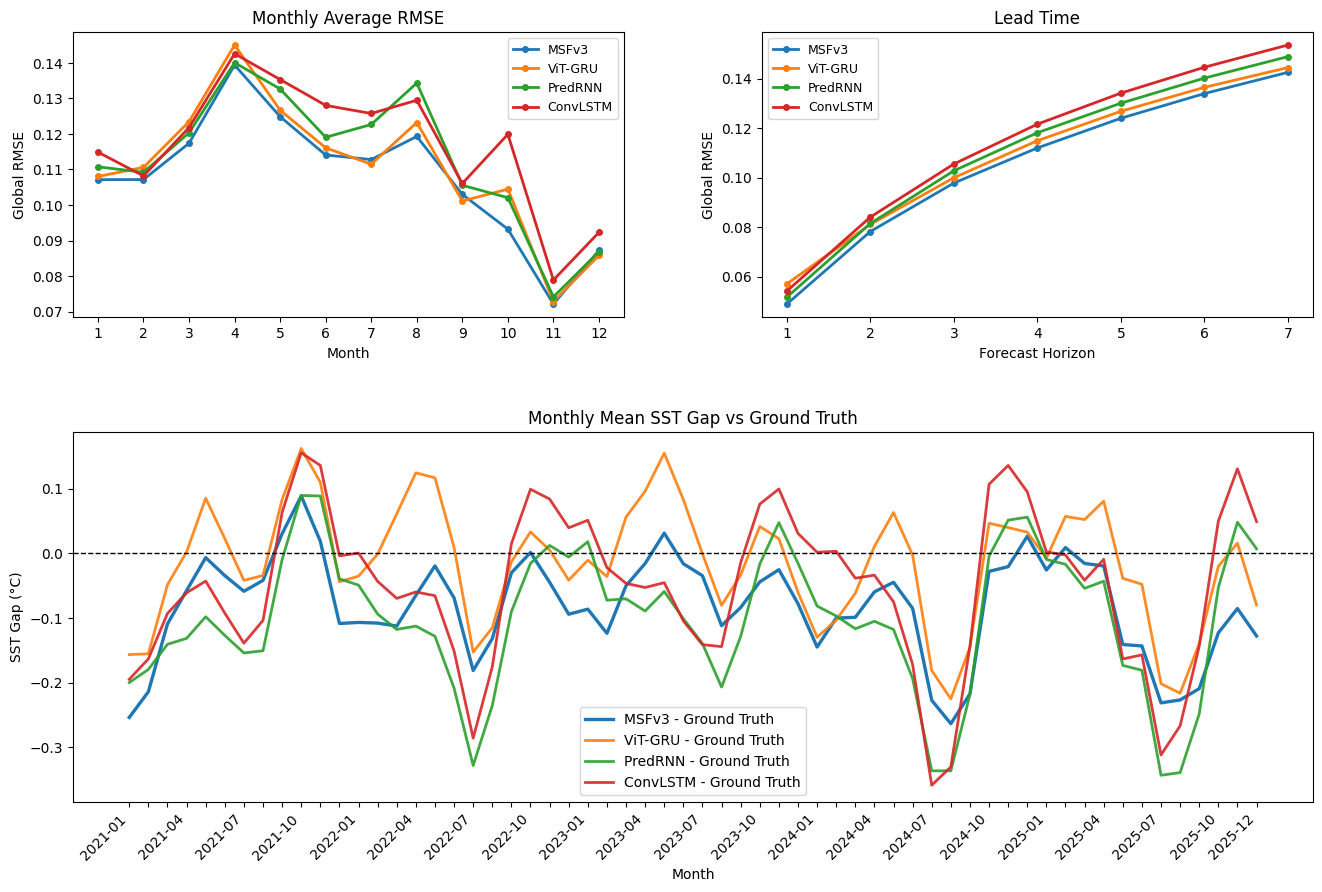

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# 공통 설정
# --------------------------------------------------
model_order = ["MSFv3", "ViT-GRU", "PredRNN", "ConvLSTM"]

# 실제 존재하는 모델만 남기기
model_order_monthly = [m for m in model_order if m in df_monthly["Model"].unique()]
model_order_horizon = [m for m in model_order if m in df_horizon["Model"].unique()]
model_order_time = [m for m in model_order if m in df_temp["Model"].unique()]

# --------------------------------------------------
# 아래쪽(모델 - GT)용 데이터 준비
# --------------------------------------------------
plot_temp_df = df_temp[df_temp["Model"].isin(["Ground Truth"] + model_order_time)].copy()
plot_temp_df["Date"] = pd.PeriodIndex(plot_temp_df["YearMonth"], freq="M").to_timestamp()
plot_temp_df = plot_temp_df.sort_values(["Model", "Date"])

if "MeanTemp_smooth" not in plot_temp_df.columns:
    plot_temp_df["MeanTemp_smooth"] = (
        plot_temp_df.groupby("Model")["MeanTemp"]
        .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).mean())
    )

pivot_temp = plot_temp_df.pivot(index="Date", columns="Model", values="MeanTemp_smooth")
ref_model = "Ground Truth"
baseline_models = [m for m in model_order_time if m in pivot_temp.columns]

temp_gap_df = pivot_temp[baseline_models].sub(pivot_temp[ref_model], axis=0)

all_dates = list(temp_gap_df.index)
all_x_labels = [d.strftime("%Y-%m") for d in all_dates]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.3],
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])   # 왼쪽 위
ax2 = fig.add_subplot(gs[0, 1])   # 오른쪽 위
ax3 = fig.add_subplot(gs[1, :])   # 아래 전체

# --------------------------------------------------
# 1) 왼쪽 위: 월별 RMSE (Month = 1~12)
# --------------------------------------------------
for model in model_order_monthly:
    sub = df_monthly[df_monthly["Model"] == model].sort_values("Month")
    ax1.plot(
        sub["Month"],
        sub["RMSE"],
        marker="o",
        markersize=4,
        linewidth=2,
        label=model
    )

ax1.set_xticks(range(1, 13))
ax1.set_xlabel("Month")
ax1.set_ylabel("Global RMSE")
ax1.set_title("Monthly Average RMSE")
ax1.legend(fontsize=9)

# --------------------------------------------------
# 2) 오른쪽 위: Horizon-wise RMSE
# --------------------------------------------------
for model in model_order_horizon:
    sub = df_horizon[df_horizon["Model"] == model].sort_values("Horizon")
    ax2.plot(
        sub["Horizon"],
        sub["RMSE"],
        marker="o",
        markersize=4,
        linewidth=2,
        label=model
    )

ax2.set_xticks(sorted(df_horizon["Horizon"].unique()))
ax2.set_xlabel("Forecast Horizon")
ax2.set_ylabel("Global RMSE")
ax2.set_title("Lead Time")
ax2.legend(fontsize=9)

# --------------------------------------------------
# 3) 아래 전체: 모델 - GT
#    양수면 모델이 GT보다 더 따뜻하게 예측
#    음수면 모델이 GT보다 더 차갑게 예측
# --------------------------------------------------
for model in baseline_models:
    lw = 2.4 if model == "MSFv3" else 2.0
    alpha = 1.0 if model == "MSFv3" else 0.9

    ax3.plot(
        range(len(temp_gap_df.index)),
        temp_gap_df[model].values,
        # marker="o",
        # markersize=4,
        linewidth=lw,
        alpha=alpha,
        label=f"{model} - {ref_model}"
    )

ax3.axhline(0, linestyle="--", linewidth=1, color="black")

tick_positions = list(range(len(all_x_labels)))
step = 3
tick_labels = [all_x_labels[i] if i % step == 0 else "" for i in range(len(all_x_labels))]
if len(all_x_labels) > 0:
    tick_labels[-1] = all_x_labels[-1]

ax3.set_xticks(tick_positions)
ax3.set_xticklabels(tick_labels, rotation=45, ha="right")
ax3.set_xlabel("Month")
ax3.set_ylabel("SST Gap (°C)")
ax3.set_title("Monthly Mean SST Gap vs Ground Truth")
ax3.legend(fontsize=10)

plt.tight_layout()
plt.savefig("results_fig1.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

/tmp/ipykernel_256482/2338556769.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


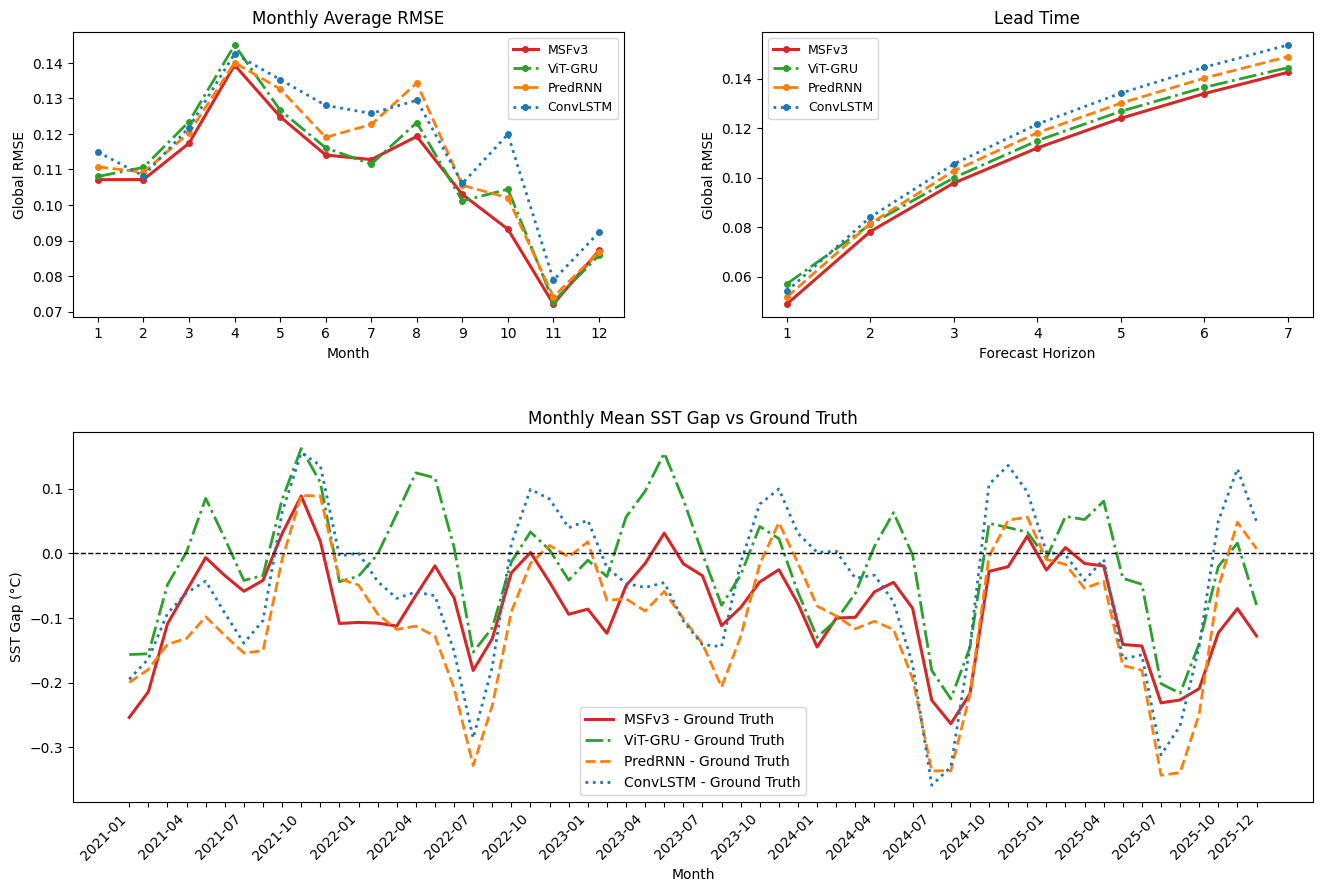

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# 공통 설정
# --------------------------------------------------
model_order = ["MSFv3", "ViT-GRU", "PredRNN", "ConvLSTM"]

# 실제 존재하는 모델만 남기기
model_order_monthly = [m for m in model_order if m in df_monthly["Model"].unique()]
model_order_horizon = [m for m in model_order if m in df_horizon["Model"].unique()]
model_order_time = [m for m in model_order if m in df_temp["Model"].unique()]

# --------------------------------------------------
# 스타일 설정
# 위 이미지처럼 "색 + 선 모양"만 변경
# --------------------------------------------------
style_map = {
    "MSFv3": {
        "color": "#d62728",   # 빨강
        "linestyle": "-",
        "linewidth": 2.2,
    },
    "ViT-GRU": {
        "color": "#2ca02c",   # 초록
        "linestyle": "-.",
        "linewidth": 2.0,
    },
    "PredRNN": {
        "color": "#ff7f0e",   # 주황
        "linestyle": "--",
        "linewidth": 2.0,
    },
    "ConvLSTM": {
        "color": "#1f77b4",   # 파랑
        "linestyle": ":",
        "linewidth": 2.0,
    },
    "Ground Truth": {
        "color": "black",
        "linestyle": "-",
        "linewidth": 2.2,
    }
}

# --------------------------------------------------
# 아래쪽(모델 - GT)용 데이터 준비
# --------------------------------------------------
plot_temp_df = df_temp[df_temp["Model"].isin(["Ground Truth"] + model_order_time)].copy()
plot_temp_df["Date"] = pd.PeriodIndex(plot_temp_df["YearMonth"], freq="M").to_timestamp()
plot_temp_df = plot_temp_df.sort_values(["Model", "Date"])

if "MeanTemp_smooth" not in plot_temp_df.columns:
    plot_temp_df["MeanTemp_smooth"] = (
        plot_temp_df.groupby("Model")["MeanTemp"]
        .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).mean())
    )

pivot_temp = plot_temp_df.pivot(index="Date", columns="Model", values="MeanTemp_smooth")
ref_model = "Ground Truth"
baseline_models = [m for m in model_order_time if m in pivot_temp.columns]

temp_gap_df = pivot_temp[baseline_models].sub(pivot_temp[ref_model], axis=0)

all_dates = list(temp_gap_df.index)
all_x_labels = [d.strftime("%Y-%m") for d in all_dates]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.3],
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])   # 왼쪽 위
ax2 = fig.add_subplot(gs[0, 1])   # 오른쪽 위
ax3 = fig.add_subplot(gs[1, :])   # 아래 전체

# --------------------------------------------------
# 1) 왼쪽 위: 월별 RMSE (Month = 1~12)
# --------------------------------------------------
for model in model_order_monthly:
    sub = df_monthly[df_monthly["Model"] == model].sort_values("Month")
    st = style_map.get(model, {})
    ax1.plot(
        sub["Month"],
        sub["RMSE"],
        marker="o",
        markersize=4,
        linewidth=st.get("linewidth", 2.0),
        linestyle=st.get("linestyle", "-"),
        color=st.get("color", None),
        label=model
    )

ax1.set_xticks(range(1, 13))
ax1.set_xlabel("Month")
ax1.set_ylabel("Global RMSE")
ax1.set_title("Monthly Average RMSE")
ax1.legend(fontsize=9)

# --------------------------------------------------
# 2) 오른쪽 위: Horizon-wise RMSE
# --------------------------------------------------
for model in model_order_horizon:
    sub = df_horizon[df_horizon["Model"] == model].sort_values("Horizon")
    st = style_map.get(model, {})
    ax2.plot(
        sub["Horizon"],
        sub["RMSE"],
        marker="o",
        markersize=4,
        linewidth=st.get("linewidth", 2.0),
        linestyle=st.get("linestyle", "-"),
        color=st.get("color", None),
        label=model
    )

ax2.set_xticks(sorted(df_horizon["Horizon"].unique()))
ax2.set_xlabel("Forecast Horizon")
ax2.set_ylabel("Global RMSE")
ax2.set_title("Lead Time")
ax2.legend(fontsize=9)

# --------------------------------------------------
# 3) 아래 전체: 모델 - GT
#    양수면 모델이 GT보다 더 따뜻하게 예측
#    음수면 모델이 GT보다 더 차갑게 예측
# --------------------------------------------------
for model in baseline_models:
    st = style_map.get(model, {})
    ax3.plot(
        range(len(temp_gap_df.index)),
        temp_gap_df[model].values,
        linewidth=st.get("linewidth", 2.0),
        linestyle=st.get("linestyle", "-"),
        color=st.get("color", None),
        alpha=1.0,
        label=f"{model} - {ref_model}"
    )

ax3.axhline(0, linestyle="--", linewidth=1, color="black")

tick_positions = list(range(len(all_x_labels)))
step = 3
tick_labels = [all_x_labels[i] if i % step == 0 else "" for i in range(len(all_x_labels))]
if len(all_x_labels) > 0:
    tick_labels[-1] = all_x_labels[-1]

ax3.set_xticks(tick_positions)
ax3.set_xticklabels(tick_labels, rotation=45, ha="right")
ax3.set_xlabel("Month")
ax3.set_ylabel("SST Gap (°C)")
ax3.set_title("Monthly Mean SST Gap vs Ground Truth")
ax3.legend(fontsize=10)

plt.tight_layout()
plt.savefig("results_fig1.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_256482/3337418078.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


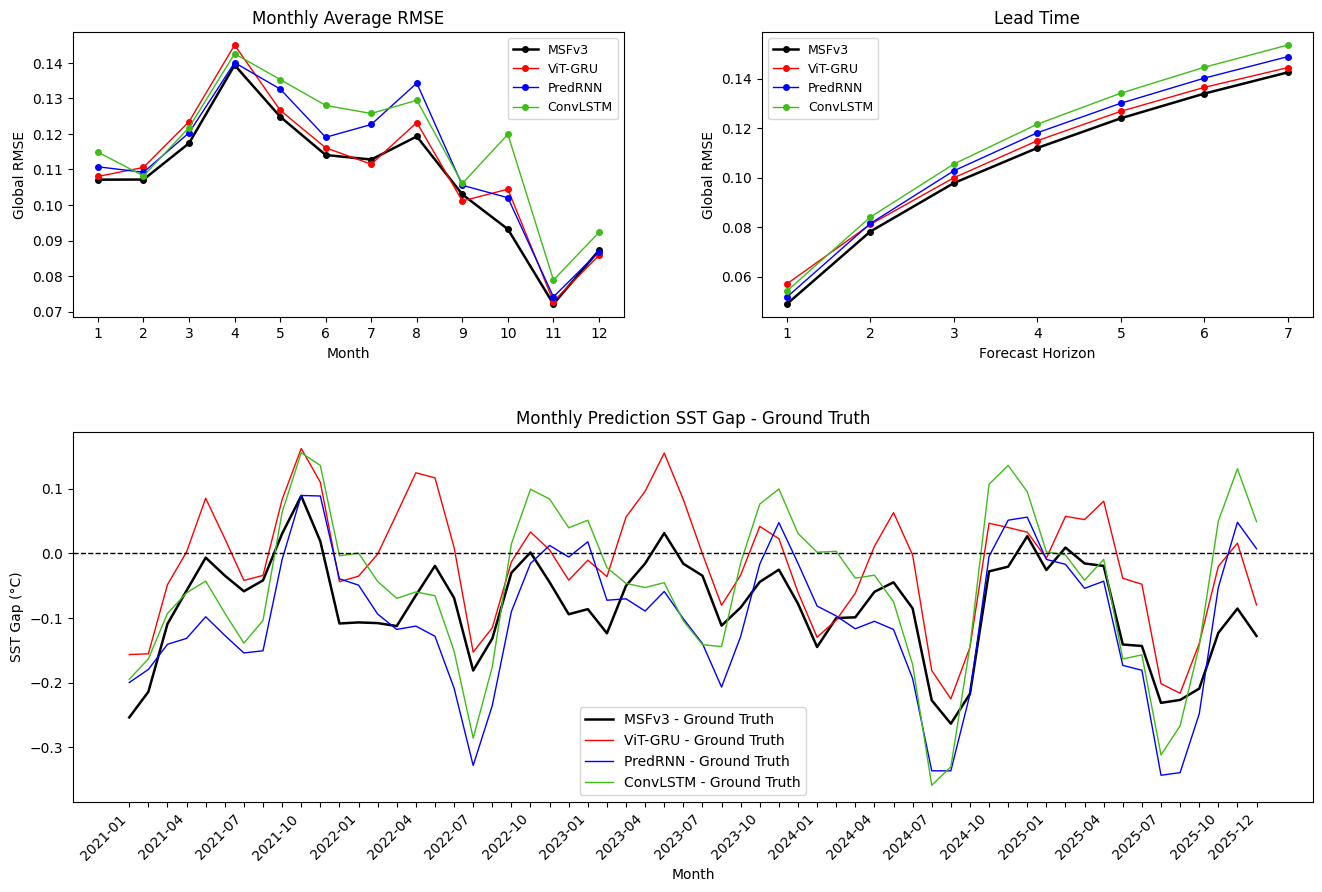

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# 공통 설정
# --------------------------------------------------
model_order = ["MSFv3", "ViT-GRU", "PredRNN", "ConvLSTM"]

# 실제 존재하는 모델만 남기기
model_order_monthly = [m for m in model_order if m in df_monthly["Model"].unique()]
model_order_horizon = [m for m in model_order if m in df_horizon["Model"].unique()]
model_order_time = [m for m in model_order if m in df_temp["Model"].unique()]

# --------------------------------------------------
# 스타일 설정
# 위 이미지처럼 "색 + 선 모양"만 변경
# --------------------------------------------------
style_map = {
    "MSFv3": {
        "color": "black",
        "linestyle": "-",
        "linewidth": 1.8,
    },
    "ViT-GRU": {
        "color": "red",
        "linestyle": "-",
        "linewidth": 1.0,
    },
    "PredRNN": {
        "color": "blue",
        "linestyle": "-",
        "linewidth": 1.0,
    },
    "ConvLSTM": {
        "color": "#3EBD18",
        "linestyle": "-",
        "linewidth": 1.0,
    },
    "Ground Truth": {
        "color": "black",
        "linestyle": "-",
        "linewidth": 1.8,
    }
}

# --------------------------------------------------
# 아래쪽(모델 - GT)용 데이터 준비
# --------------------------------------------------
plot_temp_df = df_temp[df_temp["Model"].isin(["Ground Truth"] + model_order_time)].copy()
plot_temp_df["Date"] = pd.PeriodIndex(plot_temp_df["YearMonth"], freq="M").to_timestamp()
plot_temp_df = plot_temp_df.sort_values(["Model", "Date"])

if "MeanTemp_smooth" not in plot_temp_df.columns:
    plot_temp_df["MeanTemp_smooth"] = (
        plot_temp_df.groupby("Model")["MeanTemp"]
        .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).mean())
    )

pivot_temp = plot_temp_df.pivot(index="Date", columns="Model", values="MeanTemp_smooth")
ref_model = "Ground Truth"
baseline_models = [m for m in model_order_time if m in pivot_temp.columns]

temp_gap_df = pivot_temp[baseline_models].sub(pivot_temp[ref_model], axis=0)

all_dates = list(temp_gap_df.index)
all_x_labels = [d.strftime("%Y-%m") for d in all_dates]

# --------------------------------------------------
# Figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.3],
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])   # 왼쪽 위
ax2 = fig.add_subplot(gs[0, 1])   # 오른쪽 위
ax3 = fig.add_subplot(gs[1, :])   # 아래 전체

# --------------------------------------------------
# 1) 왼쪽 위: 월별 RMSE (Month = 1~12)
# --------------------------------------------------
for model in model_order_monthly:
    sub = df_monthly[df_monthly["Model"] == model].sort_values("Month")
    st = style_map.get(model, {})
    ax1.plot(
        sub["Month"],
        sub["RMSE"],
        marker="o",
        markersize=4,
        linewidth=st.get("linewidth", 2.0),
        linestyle=st.get("linestyle", "-"),
        color=st.get("color", None),
        label=model
    )

ax1.set_xticks(range(1, 13))
ax1.set_xlabel("Month")
ax1.set_ylabel("Global RMSE")
ax1.set_title("Monthly Average RMSE")
ax1.legend(fontsize=9)

# --------------------------------------------------
# 2) 오른쪽 위: Horizon-wise RMSE
# --------------------------------------------------
for model in model_order_horizon:
    sub = df_horizon[df_horizon["Model"] == model].sort_values("Horizon")
    st = style_map.get(model, {})
    ax2.plot(
        sub["Horizon"],
        sub["RMSE"],
        marker="o",
        markersize=4,
        linewidth=st.get("linewidth", 2.0),
        linestyle=st.get("linestyle", "-"),
        color=st.get("color", None),
        label=model
    )

ax2.set_xticks(sorted(df_horizon["Horizon"].unique()))
ax2.set_xlabel("Forecast Horizon")
ax2.set_ylabel("Global RMSE")
ax2.set_title("Lead Time")
ax2.legend(fontsize=9)

# --------------------------------------------------
# 3) 아래 전체: 모델 - GT
#    양수면 모델이 GT보다 더 따뜻하게 예측
#    음수면 모델이 GT보다 더 차갑게 예측
# --------------------------------------------------
for model in baseline_models:
    st = style_map.get(model, {})
    ax3.plot(
        range(len(temp_gap_df.index)),
        temp_gap_df[model].values,
        linewidth=st.get("linewidth", 2.0),
        linestyle=st.get("linestyle", "-"),
        color=st.get("color", None),
        alpha=1.0,
        label=f"{model} - {ref_model}"
    )

ax3.axhline(0, linestyle="--", linewidth=1, color="black")

tick_positions = list(range(len(all_x_labels)))
step = 3
tick_labels = [all_x_labels[i] if i % step == 0 else "" for i in range(len(all_x_labels))]
if len(all_x_labels) > 0:
    tick_labels[-1] = all_x_labels[-1]

ax3.set_xticks(tick_positions)
ax3.set_xticklabels(tick_labels, rotation=45, ha="right")
ax3.set_xlabel("Month")
ax3.set_ylabel("SST Gap (°C)")
ax3.set_title("Monthly Prediction SST Gap - Ground Truth")
ax3.legend(fontsize=10)

plt.tight_layout()
plt.savefig("results_fig1.png", dpi=300, bbox_inches="tight")
plt.show()